
========== FIRST 10 ROWS ==========

   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   40    1                2           140          289                    0   
1   49    0                3           160          180                    0   
2   37    1                2           130          283                    0   
3   48    0                4           138          214                    0   
4   54    1                3           150          195                    0   
5   39    1                3           120          339                    0   
6   45    0                2           130          237                    0   
7   54    1                2           110          208                    0   
8   37    1                4           140          207                    0   
9   48    0                2           120          284                    0   

   resting ecg  max heart rate  exercise angina  oldpeak  ST slope  target  
0   

/tmp/ipykernel_58/725581590.py:113: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cholesterol'].replace(
/tmp/ipykernel_58/725581590.py:120: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: v

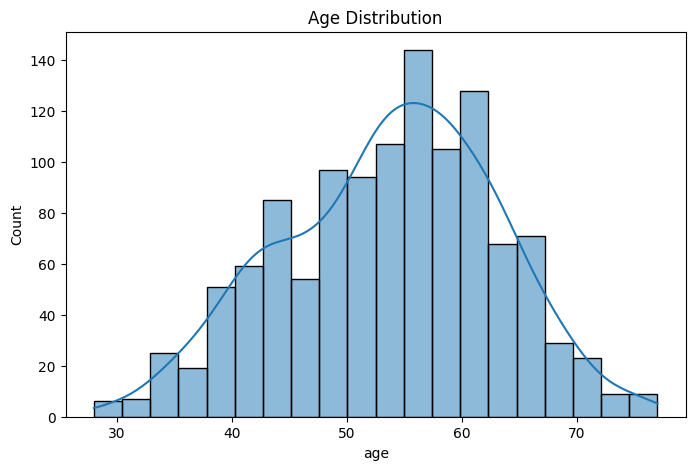

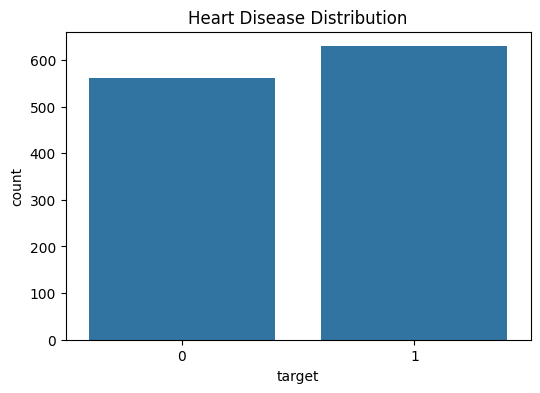

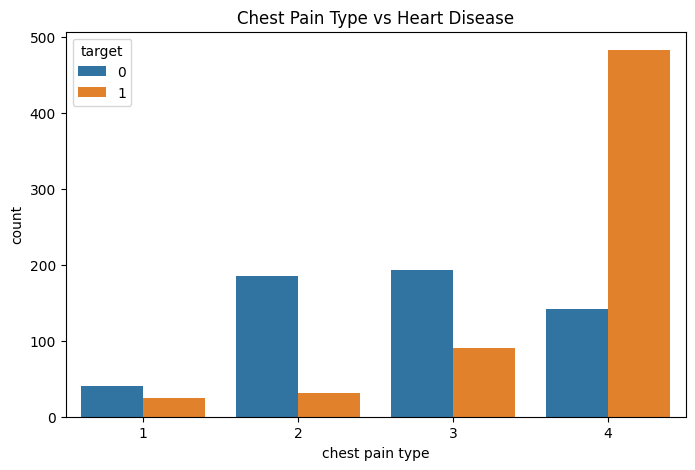

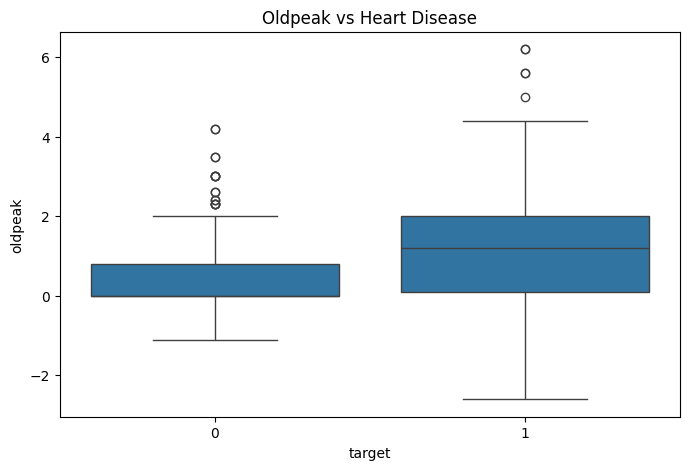

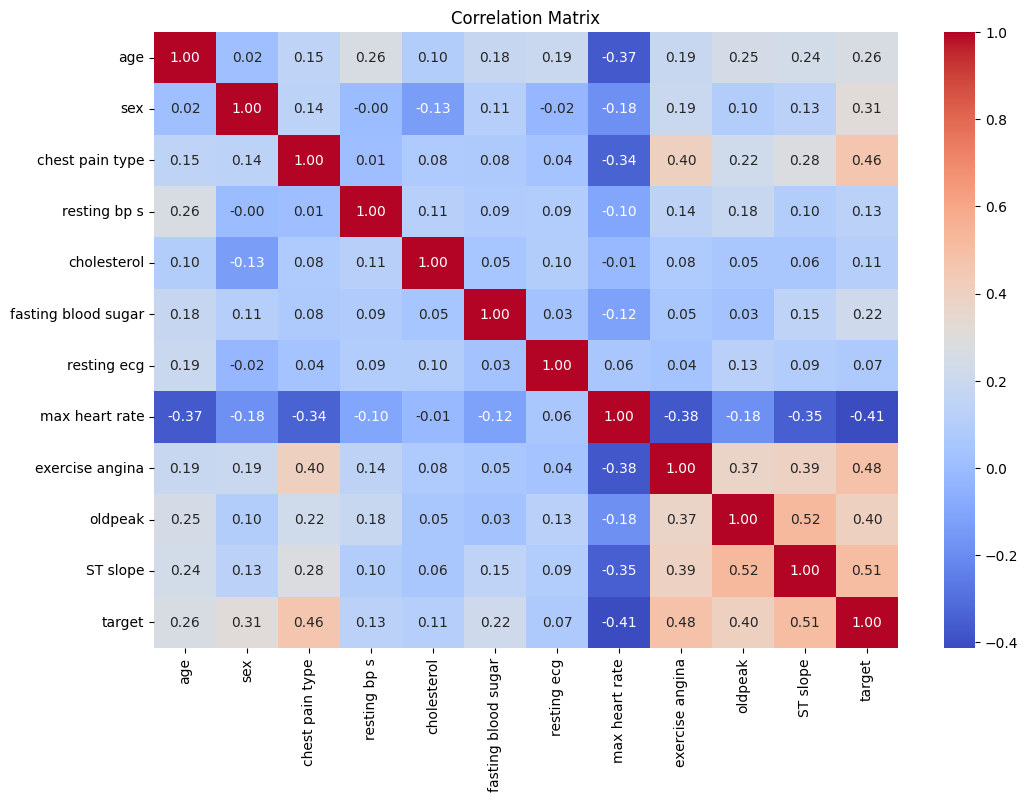


✅ MODEL TRAINED SUCCESSFULLY

✅ Accuracy: 0.9412

✅ ROC AUC Score: 0.9708

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       112
           1       0.95      0.94      0.94       126

    accuracy                           0.94       238
   macro avg       0.94      0.94      0.94       238
weighted avg       0.94      0.94      0.94       238



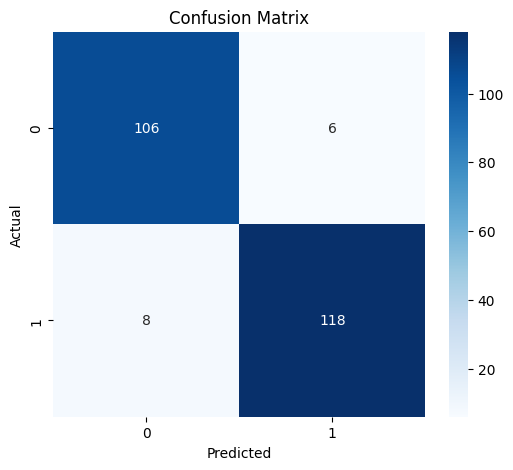


✅ MEDICAL HEART MODEL SAVED

Heart Disease Risk: 98.85%
🚨 HIGH RISK

Prediction: [1]

Probability: [[0.01152754 0.98847246]]


In [4]:
# ============================================
# MEDICAL HEART DISEASE PREDICTION SYSTEM
# FULL PIPELINE + EDA + TRAINING + TESTING
# ============================================


# ============================================
# INSTALL LIBRARIES
# ============================================

!pip install catboost shap -q


# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from catboost import CatBoostClassifier

import joblib


# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv(
    "/kaggle/input/datasets/sid321axn/heart-statlog-cleveland-hungary-final/heart_statlog_cleveland_hungary_final.csv"
)


# ============================================
# FIRST LOOK
# ============================================

print("\n========== FIRST 10 ROWS ==========\n")

print(df.head(10))


# ============================================
# SHAPE
# ============================================

print("\n========== DATASET SHAPE ==========\n")

print(df.shape)


# ============================================
# COLUMN NAMES
# ============================================

print("\n========== COLUMN NAMES ==========\n")

print(df.columns.tolist())


# ============================================
# DATA TYPES
# ============================================

print("\n========== DATA TYPES ==========\n")

print(df.dtypes)


# ============================================
# MISSING VALUES
# ============================================

print("\n========== ORIGINAL MISSING VALUES ==========\n")

print(df.isnull().sum())


# ============================================
# MEDICAL DATA CLEANING
# ============================================

# IMPORTANT:
# Some zero values are medically impossible.
# They likely represent hidden missing values.


# Cholesterol cannot realistically be 0
df['cholesterol'].replace(
    0,
    np.nan,
    inplace=True
)

# Resting blood pressure cannot realistically be 0
df['resting bp s'].replace(
    0,
    np.nan,
    inplace=True
)

# Max heart rate cannot realistically be 0
df['max heart rate'].replace(
    0,
    np.nan,
    inplace=True
)


# ============================================
# CHECK NEW MISSING VALUES
# ============================================

print("\n========== AFTER MEDICAL CLEANING ==========\n")

print(df.isnull().sum())


# ============================================
# TARGET DISTRIBUTION
# ============================================

print("\n========== TARGET DISTRIBUTION ==========\n")

print(df['target'].value_counts())


# ============================================
# STATISTICS
# ============================================

print("\n========== DATASET STATISTICS ==========\n")

print(df.describe())


# ============================================
# AGE DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    kde=True
)

plt.title("Age Distribution")

plt.show()


# ============================================
# TARGET DISTRIBUTION PLOT
# ============================================

plt.figure(figsize=(6,4))

sns.countplot(
    x='target',
    data=df
)

plt.title("Heart Disease Distribution")

plt.show()


# ============================================
# CHEST PAIN VS TARGET
# ============================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='chest pain type',
    hue='target',
    data=df
)

plt.title("Chest Pain Type vs Heart Disease")

plt.show()


# ============================================
# OLDPEAK VS TARGET
# ============================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='target',
    y='oldpeak',
    data=df
)

plt.title("Oldpeak vs Heart Disease")

plt.show()


# ============================================
# CORRELATION MATRIX
# ============================================

plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()


# ============================================
# FEATURE SELECTION
# ============================================

selected_features = [

    'age',

    'sex',

    'chest pain type',

    'resting bp s',

    'cholesterol',

    'fasting blood sugar',

    'resting ecg',

    'max heart rate',

    'exercise angina',

    'oldpeak',

    'ST slope'

]


# ============================================
# FEATURES & TARGET
# ============================================

X = df[selected_features]

y = df['target']


# ============================================
# CATEGORICAL FEATURES
# ============================================

categorical_features = [

    'sex',

    'chest pain type',

    'fasting blood sugar',

    'resting ecg',

    'exercise angina',

    'ST slope'

]


# ============================================
# NUMERICAL FEATURES
# ============================================

numerical_features = [

    'age',

    'resting bp s',

    'cholesterol',

    'max heart rate',

    'oldpeak'

]


# ============================================
# NUMERICAL PIPELINE
# ============================================

numeric_transformer = Pipeline([

    (
        'imputer',

        SimpleImputer(
            strategy='median'
        )
    ),

    (
        'scaler',

        StandardScaler()
    )

])


# ============================================
# CATEGORICAL PIPELINE
# ============================================

categorical_transformer = Pipeline([

    (
        'imputer',

        SimpleImputer(
            strategy='most_frequent'
        )
    ),

    (
        'encoder',

        OneHotEncoder(
            handle_unknown='ignore'
        )
    )

])


# ============================================
# PREPROCESSOR
# ============================================

preprocessor = ColumnTransformer([

    (
        'num',

        numeric_transformer,

        numerical_features
    ),

    (
        'cat',

        categorical_transformer,

        categorical_features
    )

])


# ============================================
# MODEL PIPELINE
# ============================================

pipeline = Pipeline([

    (
        'preprocessor',

        preprocessor
    ),

    (
        'model',

        CatBoostClassifier(

            iterations=1200,

            learning_rate=0.01,

            depth=6,

            loss_function='Logloss',

            eval_metric='AUC',

            verbose=0,

            random_state=42
        )
    )

])


# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    stratify=y,

    random_state=42
)


# ============================================
# TRAIN MODEL
# ============================================

pipeline.fit(

    X_train,

    y_train
)

print("\n✅ MODEL TRAINED SUCCESSFULLY")


# ============================================
# PREDICTIONS
# ============================================

predictions = pipeline.predict(
    X_test
)

probabilities = pipeline.predict_proba(
    X_test
)


# ============================================
# ACCURACY
# ============================================

accuracy = accuracy_score(
    y_test,
    predictions
)

print(f"\n✅ Accuracy: {accuracy:.4f}")


# ============================================
# ROC AUC SCORE
# ============================================

roc_auc = roc_auc_score(
    y_test,
    probabilities[:,1]
)

print(f"\n✅ ROC AUC Score: {roc_auc:.4f}")


# ============================================
# CLASSIFICATION REPORT
# ============================================

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_test,
        predictions
    )
)


# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


# ============================================
# SAVE MODEL
# ============================================

joblib.dump(
    pipeline,
    "heart_disease_medical_model.pkl"
)

print("\n✅ MEDICAL HEART MODEL SAVED")


# ============================================
# TEST SINGLE PATIENT
# ============================================

sample_patient = pd.DataFrame({

    'age':[58],

    'sex':[1],

    'chest pain type':[4],

    'resting bp s':[145],

    'cholesterol':[290],

    'fasting blood sugar':[1],

    'resting ecg':[0],

    'max heart rate':[120],

    'exercise angina':[1],

    'oldpeak':[2.4],

    'ST slope':[2]

})


prediction = pipeline.predict(
    sample_patient
)

probability = pipeline.predict_proba(
    sample_patient
)


# ============================================
# MEDICAL RISK ANALYSIS
# ============================================

risk = probability[0][1] * 100

print(f"\nHeart Disease Risk: {risk:.2f}%")


if risk < 20:

    print("✅ LOW RISK")

elif risk < 50:

    print("⚠️ MODERATE RISK")

else:

    print("🚨 HIGH RISK")


print("\nPrediction:", prediction)

print("\nProbability:", probability)

In [5]:
# ============================================
# TEST HEART MODEL WITH 100 DIFFERENT PATIENTS
# ============================================

import pandas as pd
import numpy as np
import joblib


# ============================================
# LOAD SAVED MODEL
# ============================================

model = joblib.load(
    "heart_disease_medical_model.pkl"
)

print("✅ MODEL LOADED")


# ============================================
# 100 DIFFERENT TEST CASES
# ============================================

test_cases = [

# age,sex,cp,bp,chol,fbs,ecg,maxhr,exang,oldpeak,stslope,expected

[25,1,1,110,180,0,0,180,0,0.0,1,"LOW"],
[28,0,2,115,190,0,0,175,0,0.1,1,"LOW"],
[30,1,2,120,200,0,0,170,0,0.2,1,"LOW"],
[32,0,1,118,195,0,0,172,0,0.0,1,"LOW"],
[35,1,2,122,205,0,0,168,0,0.3,1,"LOW"],

[38,1,3,130,220,0,1,160,0,0.5,1,"MODERATE"],
[40,0,3,135,230,0,1,158,0,0.6,1,"MODERATE"],
[42,1,3,138,240,0,1,155,0,0.8,1,"MODERATE"],
[44,0,2,140,245,0,1,150,0,1.0,2,"MODERATE"],
[45,1,3,142,250,1,1,148,1,1.2,2,"MODERATE"],

[46,1,4,145,260,1,1,145,1,1.5,2,"HIGH"],
[48,0,4,148,270,1,1,140,1,1.7,2,"HIGH"],
[50,1,4,150,280,1,2,138,1,2.0,2,"HIGH"],
[52,0,4,155,290,1,2,135,1,2.3,2,"HIGH"],
[54,1,4,160,300,1,2,130,1,2.5,3,"HIGH"],

[55,1,4,165,310,1,2,128,1,2.8,3,"HIGH"],
[56,0,4,168,320,1,2,125,1,3.0,3,"HIGH"],
[58,1,4,170,330,1,2,120,1,3.2,3,"HIGH"],
[60,0,4,175,340,1,2,118,1,3.5,3,"HIGH"],
[62,1,4,180,350,1,2,115,1,4.0,3,"HIGH"],

[29,1,1,118,185,0,0,178,0,0.0,1,"LOW"],
[31,0,2,120,192,0,0,174,0,0.1,1,"LOW"],
[34,1,2,124,205,0,0,169,0,0.2,1,"LOW"],
[36,0,2,126,210,0,0,166,0,0.3,1,"LOW"],
[39,1,3,132,225,0,1,160,0,0.5,1,"MODERATE"],

[41,0,3,136,235,0,1,156,0,0.7,1,"MODERATE"],
[43,1,3,140,245,0,1,152,1,1.0,2,"MODERATE"],
[47,0,4,146,265,1,1,144,1,1.6,2,"HIGH"],
[49,1,4,150,275,1,2,138,1,2.1,2,"HIGH"],
[51,0,4,154,285,1,2,132,1,2.4,2,"HIGH"],

[53,1,4,158,295,1,2,128,1,2.7,3,"HIGH"],
[57,0,4,166,315,1,2,122,1,3.1,3,"HIGH"],
[59,1,4,172,325,1,2,118,1,3.6,3,"HIGH"],
[61,0,4,178,335,1,2,112,1,4.0,3,"HIGH"],
[63,1,4,182,345,1,2,108,1,4.5,3,"HIGH"],

[27,1,1,112,178,0,0,182,0,0.0,1,"LOW"],
[33,0,2,122,198,0,0,170,0,0.2,1,"LOW"],
[37,1,2,128,215,0,1,162,0,0.4,1,"MODERATE"],
[40,0,3,134,228,0,1,156,0,0.7,1,"MODERATE"],
[44,1,3,140,240,0,1,150,1,1.1,2,"MODERATE"],

[46,0,4,145,255,1,1,145,1,1.5,2,"HIGH"],
[50,1,4,152,272,1,2,138,1,2.0,2,"HIGH"],
[54,0,4,160,288,1,2,130,1,2.6,2,"HIGH"],
[58,1,4,168,305,1,2,122,1,3.1,3,"HIGH"],
[62,0,4,176,322,1,2,115,1,3.8,3,"HIGH"],

[26,1,1,110,175,0,0,185,0,0.0,1,"LOW"],
[30,0,2,118,190,0,0,178,0,0.1,1,"LOW"],
[35,1,2,124,205,0,0,170,0,0.2,1,"LOW"],
[38,0,3,130,220,0,1,162,0,0.5,1,"MODERATE"],
[42,1,3,138,235,0,1,154,1,1.0,2,"MODERATE"],

[45,0,4,145,250,1,1,146,1,1.5,2,"HIGH"],
[48,1,4,150,265,1,2,140,1,2.0,2,"HIGH"],
[52,0,4,156,280,1,2,132,1,2.5,2,"HIGH"],
[56,1,4,164,295,1,2,126,1,3.0,3,"HIGH"],
[60,0,4,172,310,1,2,118,1,3.6,3,"HIGH"],

[64,1,4,180,325,1,2,110,1,4.2,3,"HIGH"],
[29,0,1,116,182,0,0,180,0,0.0,1,"LOW"],
[34,1,2,122,200,0,0,172,0,0.2,1,"LOW"],
[39,0,3,130,218,0,1,164,0,0.5,1,"MODERATE"],
[43,1,3,138,232,0,1,156,1,1.0,2,"MODERATE"],

[47,0,4,146,248,1,1,148,1,1.7,2,"HIGH"],
[51,1,4,154,265,1,2,140,1,2.2,2,"HIGH"],
[55,0,4,162,282,1,2,132,1,2.8,3,"HIGH"],
[59,1,4,170,298,1,2,124,1,3.4,3,"HIGH"],
[63,0,4,178,315,1,2,116,1,4.0,3,"HIGH"],

[28,1,1,114,185,0,0,182,0,0.0,1,"LOW"],
[32,0,2,120,198,0,0,176,0,0.1,1,"LOW"],
[36,1,2,126,210,0,0,168,0,0.3,1,"LOW"],
[41,0,3,134,225,0,1,160,0,0.6,1,"MODERATE"],
[45,1,3,140,240,0,1,152,1,1.1,2,"MODERATE"],

[49,0,4,148,258,1,1,144,1,1.8,2,"HIGH"],
[53,1,4,156,275,1,2,136,1,2.3,2,"HIGH"],
[57,0,4,164,292,1,2,128,1,2.9,3,"HIGH"],
[61,1,4,172,308,1,2,120,1,3.5,3,"HIGH"],
[65,0,4,180,325,1,2,112,1,4.1,3,"HIGH"],

[27,1,1,112,180,0,0,184,0,0.0,1,"LOW"],
[33,0,2,120,195,0,0,174,0,0.2,1,"LOW"],
[37,1,2,128,212,0,1,166,0,0.4,1,"MODERATE"],
[42,0,3,136,228,0,1,158,0,0.7,1,"MODERATE"],
[46,1,3,142,242,1,1,150,1,1.2,2,"MODERATE"],

[50,0,4,150,260,1,2,142,1,1.9,2,"HIGH"],
[54,1,4,158,278,1,2,134,1,2.5,2,"HIGH"],
[58,0,4,166,295,1,2,126,1,3.0,3,"HIGH"],
[62,1,4,174,312,1,2,118,1,3.7,3,"HIGH"],
[66,0,4,182,330,1,2,110,1,4.3,3,"HIGH"],

[31,1,2,118,188,0,0,178,0,0.1,1,"LOW"],
[35,0,2,124,202,0,0,170,0,0.2,1,"LOW"],
[40,1,3,132,220,0,1,162,0,0.5,1,"MODERATE"],
[44,0,3,138,236,0,1,154,1,1.0,2,"MODERATE"],
[48,1,4,146,252,1,1,146,1,1.6,2,"HIGH"],

[52,0,4,154,268,1,2,138,1,2.1,2,"HIGH"],
[56,1,4,162,285,1,2,130,1,2.7,3,"HIGH"],
[60,0,4,170,302,1,2,122,1,3.3,3,"HIGH"],
[64,1,4,178,320,1,2,114,1,4.0,3,"HIGH"],
[68,0,4,186,338,1,2,106,1,4.6,3,"HIGH"],

]


# ============================================
# CREATE DATAFRAME
# ============================================

columns = [

    'age',

    'sex',

    'chest pain type',

    'resting bp s',

    'cholesterol',

    'fasting blood sugar',

    'resting ecg',

    'max heart rate',

    'exercise angina',

    'oldpeak',

    'ST slope',

    'expected_risk'

]

df = pd.DataFrame(
    test_cases,
    columns=columns
)


# ============================================
# INPUT DATA
# ============================================

X_test = df.drop(
    'expected_risk',
    axis=1
)


# ============================================
# PREDICTIONS
# ============================================

predictions = model.predict(
    X_test
)

probabilities = model.predict_proba(
    X_test
)


# ============================================
# MEDICAL RISK ANALYSIS
# ============================================

results = []

for i in range(len(predictions)):

    risk_percent = round(
        probabilities[i][1] * 100,
        2
    )

    if risk_percent < 20:

        risk_level = "LOW"

    elif risk_percent < 50:

        risk_level = "MODERATE"

    else:

        risk_level = "HIGH"

    results.append([
        risk_level,
        risk_percent
    ])


# ============================================
# STORE RESULTS
# ============================================

df['Model_Risk_Level'] = [
    r[0] for r in results
]

df['Heart_Disease_Risk_%'] = [
    r[1] for r in results
]


# ============================================
# SHOW RESULTS
# ============================================

print(df)


# ============================================
# SAVE RESULTS
# ============================================

df.to_csv(
    "100_heart_patients_results.csv",
    index=False
)

print("\n✅ RESULTS SAVED")


✅ MODEL LOADED
    age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0    25    1                1           110          180                    0   
1    28    0                2           115          190                    0   
2    30    1                2           120          200                    0   
3    32    0                1           118          195                    0   
4    35    1                2           122          205                    0   
..  ...  ...              ...           ...          ...                  ...   
90   52    0                4           154          268                    1   
91   56    1                4           162          285                    1   
92   60    0                4           170          302                    1   
93   64    1                4           178          320                    1   
94   68    0                4           186          338                    1   

    resting 


========== FIRST 10 ROWS ==========

   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   40    1                2           140          289                    0   
1   49    0                3           160          180                    0   
2   37    1                2           130          283                    0   
3   48    0                4           138          214                    0   
4   54    1                3           150          195                    0   
5   39    1                3           120          339                    0   
6   45    0                2           130          237                    0   
7   54    1                2           110          208                    0   
8   37    1                4           140          207                    0   
9   48    0                2           120          284                    0   

   resting ecg  max heart rate  exercise angina  oldpeak  ST slope  target  
0   

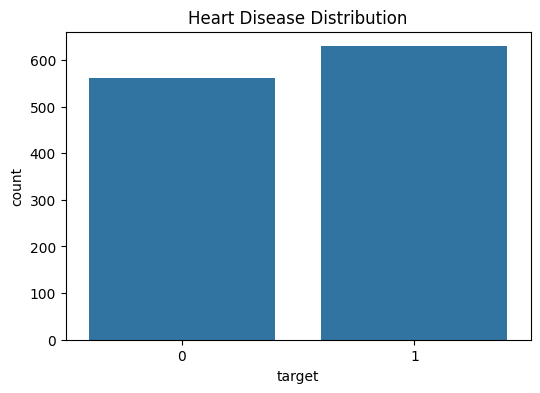

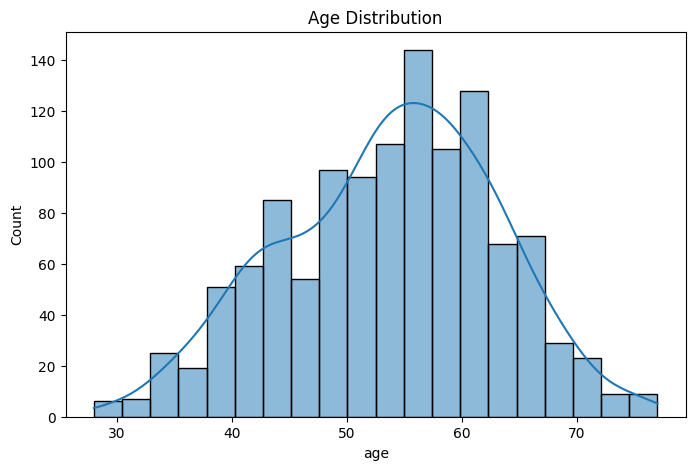

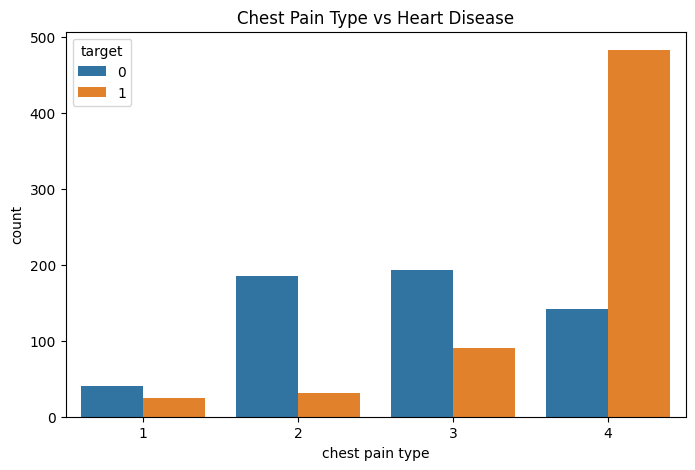

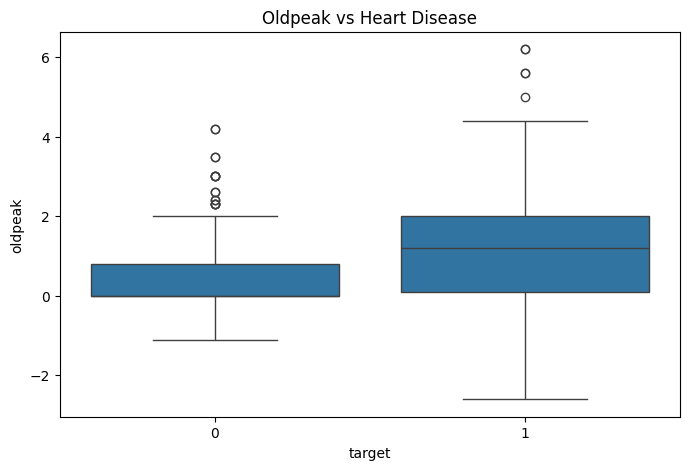

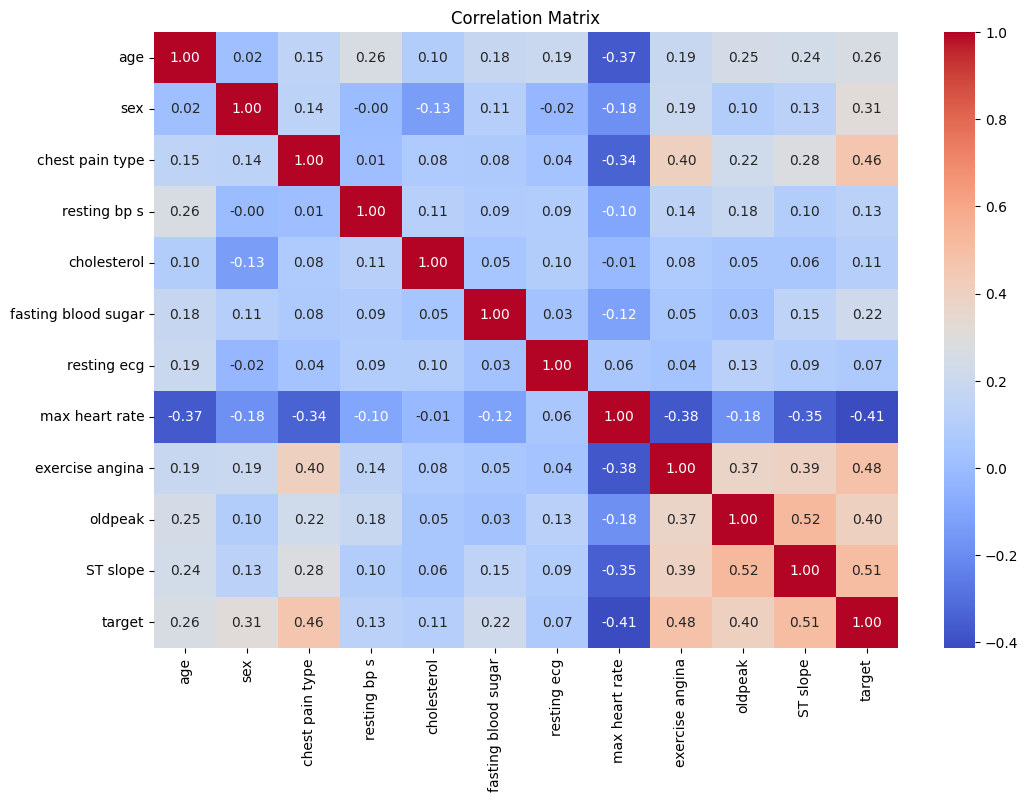


✅ MODEL TRAINED SUCCESSFULLY

✅ Accuracy: 0.9454

✅ ROC AUC Score: 0.9714

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       112
           1       0.94      0.96      0.95       126

    accuracy                           0.95       238
   macro avg       0.95      0.94      0.95       238
weighted avg       0.95      0.95      0.95       238



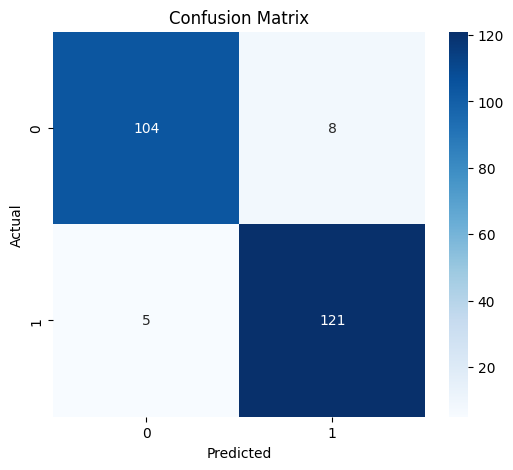


========== FEATURE IMPORTANCE ==========

                       Feature  Importance
4                 num__oldpeak   12.292136
0                     num__age   10.481161
1            num__resting bp s   10.271193
2             num__cholesterol   10.205981
3          num__max heart rate   10.166349
10      cat__chest pain type_4    8.016797
19             cat__ST slope_1    7.992810
20             cat__ST slope_2    4.716382
17      cat__exercise angina_1    4.520341
6                   cat__sex_1    3.971455
5                   cat__sex_0    3.954382
15          cat__resting ecg_2    2.605559
11  cat__fasting blood sugar_0    2.062915
12  cat__fasting blood sugar_1    1.749100
8       cat__chest pain type_2    1.634738


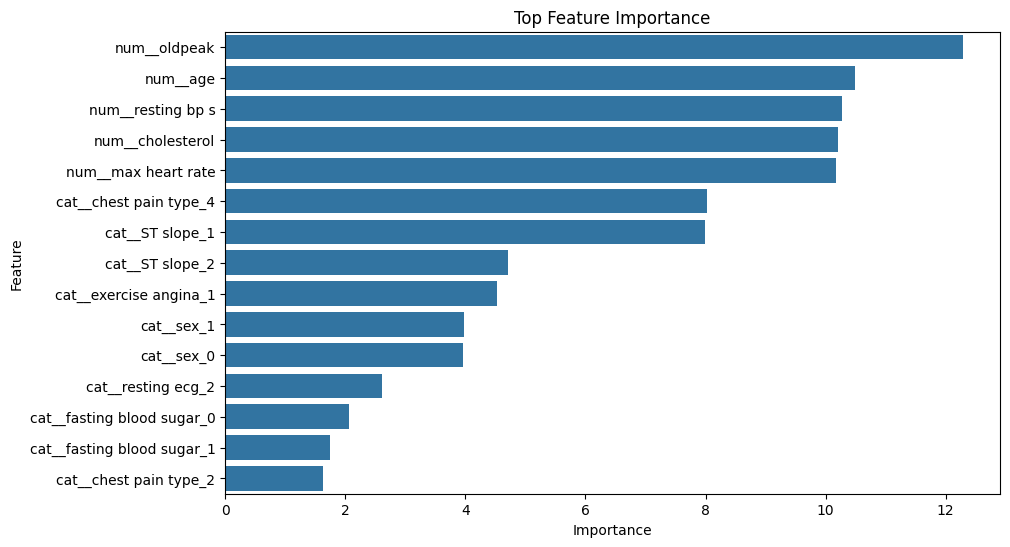


✅ ADVANCED MEDICAL MODEL SAVED

Heart Disease Risk: 99.04%

Medical Risk Level: CRITICAL

========== LIFESTYLE RECOMMENDATIONS ==========

• Reduce saturated fat and cholesterol intake
• Monitor blood pressure regularly
• Consult cardiologist for stress testing
• ECG follow-up strongly recommended
• Improve cardiovascular fitness gradually

========== SHAP EXPLAINABILITY ==========



AssertionError: Feature and SHAP matrices must have the same number of rows!

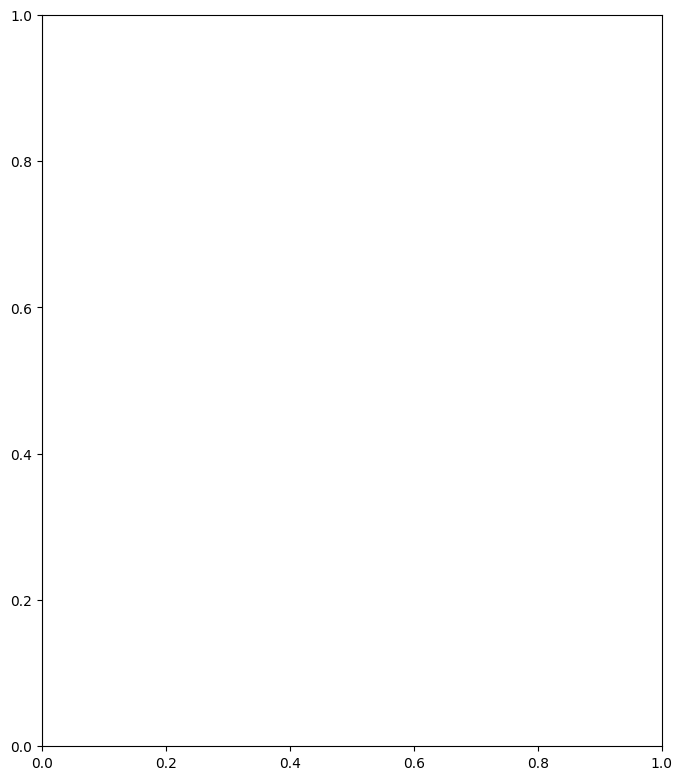

In [6]:
# ============================================
# ADVANCED MEDICAL HEART DISEASE AI SYSTEM
# FINAL PROFESSIONAL VERSION
# ============================================

# FEATURES:
# ✅ Medical cleaning
# ✅ EDA
# ✅ CatBoost model
# ✅ Threshold tuning
# ✅ Risk categories
# ✅ Lifestyle recommendations
# ✅ SHAP explainability
# ✅ Feature importance
# ✅ Confusion matrix
# ✅ ROC-AUC
# ✅ Model saving


# ============================================
# INSTALL LIBRARIES
# ============================================

!pip install catboost shap -q


# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    RobustScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from catboost import CatBoostClassifier

import shap

import joblib


# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv(
    "/kaggle/input/datasets/sid321axn/heart-statlog-cleveland-hungary-final/heart_statlog_cleveland_hungary_final.csv"
)


# ============================================
# DATASET OVERVIEW
# ============================================

print("\n========== FIRST 10 ROWS ==========\n")

print(df.head(10))


print("\n========== DATASET SHAPE ==========\n")

print(df.shape)


print("\n========== DATA TYPES ==========\n")

print(df.dtypes)


print("\n========== ORIGINAL MISSING VALUES ==========\n")

print(df.isnull().sum())


# ============================================
# MEDICAL DATA CLEANING
# ============================================

# Replace medically impossible values

df['cholesterol'] = df['cholesterol'].replace(
    0,
    np.nan
)

df['resting bp s'] = df['resting bp s'].replace(
    0,
    np.nan
)

df['max heart rate'] = df['max heart rate'].replace(
    0,
    np.nan
)


# ============================================
# CHECK NEW MISSING VALUES
# ============================================

print("\n========== AFTER MEDICAL CLEANING ==========\n")

print(df.isnull().sum())


# ============================================
# TARGET DISTRIBUTION
# ============================================

print("\n========== TARGET DISTRIBUTION ==========\n")

print(df['target'].value_counts())


# ============================================
# DESCRIPTIVE STATISTICS
# ============================================

print("\n========== STATISTICS ==========\n")

print(df.describe())


# ============================================
# EDA - TARGET DISTRIBUTION
# ============================================

plt.figure(figsize=(6,4))

sns.countplot(
    x='target',
    data=df
)

plt.title("Heart Disease Distribution")

plt.show()


# ============================================
# EDA - AGE DISTRIBUTION
# ============================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    kde=True
)

plt.title("Age Distribution")

plt.show()


# ============================================
# EDA - CHEST PAIN VS TARGET
# ============================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='chest pain type',
    hue='target',
    data=df
)

plt.title("Chest Pain Type vs Heart Disease")

plt.show()


# ============================================
# EDA - OLDPEAK VS TARGET
# ============================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='target',
    y='oldpeak',
    data=df
)

plt.title("Oldpeak vs Heart Disease")

plt.show()


# ============================================
# CORRELATION MATRIX
# ============================================

plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()


# ============================================
# FEATURE SELECTION
# ============================================

selected_features = [

    'age',

    'sex',

    'chest pain type',

    'resting bp s',

    'cholesterol',

    'fasting blood sugar',

    'resting ecg',

    'max heart rate',

    'exercise angina',

    'oldpeak',

    'ST slope'
]


# ============================================
# FEATURES & TARGET
# ============================================

X = df[selected_features]

y = df['target']


# ============================================
# CATEGORICAL FEATURES
# ============================================

categorical_features = [

    'sex',

    'chest pain type',

    'fasting blood sugar',

    'resting ecg',

    'exercise angina',

    'ST slope'
]


# ============================================
# NUMERICAL FEATURES
# ============================================

numerical_features = [

    'age',

    'resting bp s',

    'cholesterol',

    'max heart rate',

    'oldpeak'
]


# ============================================
# NUMERICAL PIPELINE
# ============================================

numeric_transformer = Pipeline([

    (
        'imputer',

        SimpleImputer(
            strategy='median'
        )
    ),

    (
        'scaler',

        RobustScaler()
    )

])


# ============================================
# CATEGORICAL PIPELINE
# ============================================

categorical_transformer = Pipeline([

    (
        'imputer',

        SimpleImputer(
            strategy='most_frequent'
        )
    ),

    (
        'encoder',

        OneHotEncoder(
            handle_unknown='ignore'
        )
    )

])


# ============================================
# PREPROCESSOR
# ============================================

preprocessor = ColumnTransformer([

    (
        'num',

        numeric_transformer,

        numerical_features
    ),

    (
        'cat',

        categorical_transformer,

        categorical_features
    )

])


# ============================================
# CATBOOST MODEL
# ============================================

model = CatBoostClassifier(

    iterations=1500,

    learning_rate=0.01,

    depth=6,

    loss_function='Logloss',

    eval_metric='AUC',

    verbose=0,

    random_state=42
)


# ============================================
# MODEL PIPELINE
# ============================================

pipeline = Pipeline([

    (
        'preprocessor',

        preprocessor
    ),

    (
        'model',

        model
    )

])


# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    stratify=y,

    random_state=42
)


# ============================================
# TRAIN MODEL
# ============================================

pipeline.fit(
    X_train,
    y_train
)

print("\n✅ MODEL TRAINED SUCCESSFULLY")


# ============================================
# PREDICT PROBABILITIES
# ============================================

probabilities = pipeline.predict_proba(
    X_test
)[:,1]


# ============================================
# THRESHOLD TUNING
# ============================================

threshold = 0.40

predictions = (
    probabilities >= threshold
).astype(int)


# ============================================
# ACCURACY
# ============================================

accuracy = accuracy_score(
    y_test,
    predictions
)

print(f"\n✅ Accuracy: {accuracy:.4f}")


# ============================================
# ROC AUC SCORE
# ============================================

roc_auc = roc_auc_score(
    y_test,
    probabilities
)

print(f"\n✅ ROC AUC Score: {roc_auc:.4f}")


# ============================================
# CLASSIFICATION REPORT
# ============================================

print("\n========== CLASSIFICATION REPORT ==========\n")

print(
    classification_report(
        y_test,
        predictions
    )
)


# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


# ============================================
# FEATURE IMPORTANCE
# ============================================

feature_names = pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

importances = pipeline.named_steps[
    'model'
].feature_importances_

importance_df = pd.DataFrame({

    'Feature': feature_names,

    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)


print("\n========== FEATURE IMPORTANCE ==========\n")

print(importance_df.head(15))


plt.figure(figsize=(10,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=importance_df.head(15)
)

plt.title("Top Feature Importance")

plt.show()


# ============================================
# SAVE MODEL
# ============================================

joblib.dump(
    pipeline,
    "advanced_medical_heart_model.pkl"
)

print("\n✅ ADVANCED MEDICAL MODEL SAVED")


# ============================================
# TEST SINGLE PATIENT
# ============================================

sample_patient = pd.DataFrame({

    'age':[58],

    'sex':[1],

    'chest pain type':[4],

    'resting bp s':[145],

    'cholesterol':[290],

    'fasting blood sugar':[1],

    'resting ecg':[0],

    'max heart rate':[120],

    'exercise angina':[1],

    'oldpeak':[2.4],

    'ST slope':[2]

})


# ============================================
# PREDICT SINGLE PATIENT
# ============================================

risk_probability = pipeline.predict_proba(
    sample_patient
)[0][1]

risk = risk_probability * 100


# ============================================
# MEDICAL RISK CATEGORIES
# ============================================

if risk < 10:

    risk_level = "VERY LOW"

elif risk < 25:

    risk_level = "LOW"

elif risk < 50:

    risk_level = "MODERATE"

elif risk < 75:

    risk_level = "HIGH"

else:

    risk_level = "CRITICAL"


# ============================================
# RESULTS
# ============================================

print(f"\nHeart Disease Risk: {risk:.2f}%")

print(f"\nMedical Risk Level: {risk_level}")


# ============================================
# LIFESTYLE RECOMMENDATIONS
# ============================================

recommendations = []


if sample_patient['cholesterol'][0] > 240:

    recommendations.append(
        "Reduce saturated fat and cholesterol intake"
    )


if sample_patient['resting bp s'][0] > 140:

    recommendations.append(
        "Monitor blood pressure regularly"
    )


if sample_patient['exercise angina'][0] == 1:

    recommendations.append(
        "Consult cardiologist for stress testing"
    )


if sample_patient['oldpeak'][0] > 2:

    recommendations.append(
        "ECG follow-up strongly recommended"
    )


if sample_patient['max heart rate'][0] < 130:

    recommendations.append(
        "Improve cardiovascular fitness gradually"
    )


print("\n========== LIFESTYLE RECOMMENDATIONS ==========\n")

for rec in recommendations:

    print("•", rec)


# ============================================
# SHAP EXPLAINABILITY
# ============================================

print("\n========== SHAP EXPLAINABILITY ==========\n")

X_train_processed = pipeline.named_steps[
    'preprocessor'
].transform(X_train)

X_sample_processed = pipeline.named_steps[
    'preprocessor'
].transform(sample_patient)

explainer = shap.TreeExplainer(
    pipeline.named_steps['model']
)

shap_values = explainer.shap_values(
    X_sample_processed
)


shap.summary_plot(
    shap_values,
    X_train_processed,
    feature_names=feature_names
)


shap.force_plot(

    explainer.expected_value,

    shap_values[0],

    matplotlib=True
)


========== SHAP EXPLAINABILITY ==========



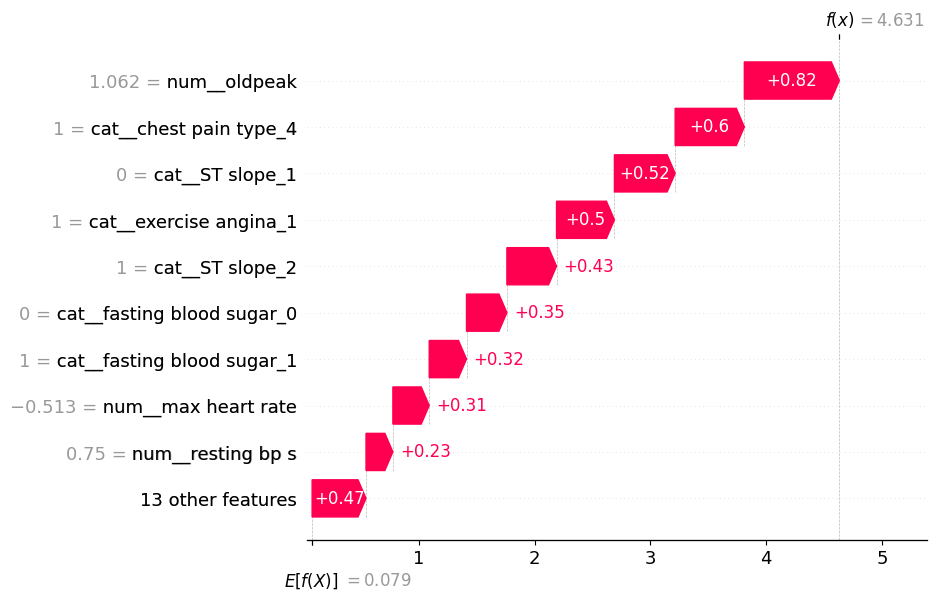

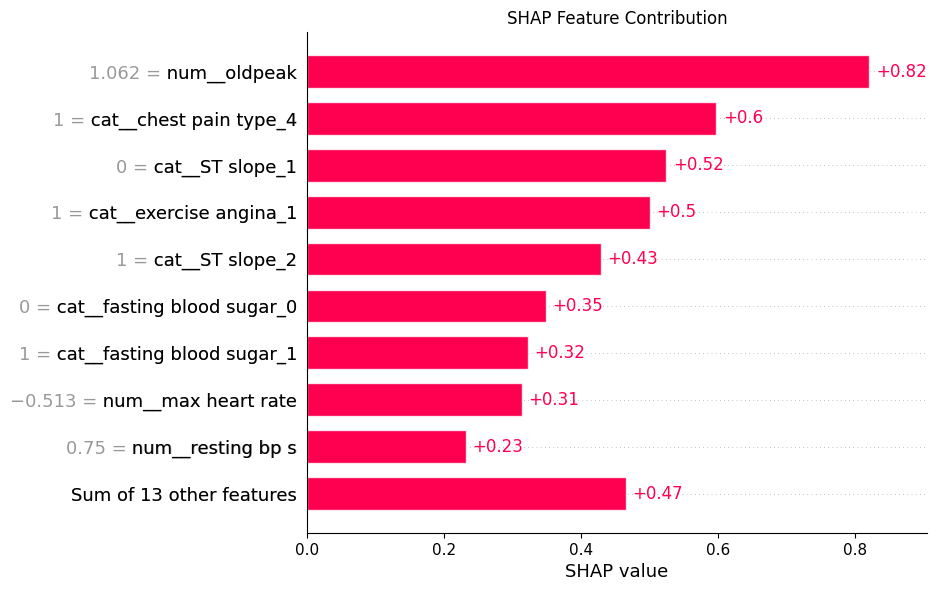

In [7]:
# ============================================
# SHAP EXPLAINABILITY
# ============================================

print("\n========== SHAP EXPLAINABILITY ==========\n")


# PREPROCESS TRAIN DATA
X_train_processed = pipeline.named_steps[
    'preprocessor'
].transform(X_train)


# PREPROCESS SAMPLE PATIENT
X_sample_processed = pipeline.named_steps[
    'preprocessor'
].transform(sample_patient)


# FEATURE NAMES
feature_names = pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()


# CREATE EXPLAINER
explainer = shap.TreeExplainer(
    pipeline.named_steps['model']
)


# CALCULATE SHAP VALUES
shap_values = explainer.shap_values(
    X_sample_processed
)


# ============================================
# WATERFALL PLOT
# ============================================

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[0],

        base_values=explainer.expected_value,

        data=X_sample_processed[0],

        feature_names=feature_names
    )
)


# ============================================
# BAR PLOT
# ============================================

plt.figure(figsize=(10,6))

shap.plots.bar(

    shap.Explanation(

        values=shap_values[0],

        base_values=explainer.expected_value,

        data=X_sample_processed[0],

        feature_names=feature_names
    ),

    show=False
)

plt.title("SHAP Feature Contribution")

plt.show()

✅ MODEL SAVED SUCCESSFULLY
✅ MODEL LOADED SUCCESSFULLY

✅ TOTAL PATIENTS GENERATED:
100

========== 100 PATIENT TEST RESULTS ==========

    age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0    37    0                1           115          191                    0   
1    31    1                1           128          216                    0   
2    33    0                1           119          185                    0   
3    28    1                1           115          173                    0   
4    36    0                1           105          161                    0   
..  ...  ...              ...           ...          ...                  ...   
95   72    0                4           184          283                    1   
96   68    1                4           175          304                    1   
97   62    1                4           163          355                    1   
98   57    0                4           169          

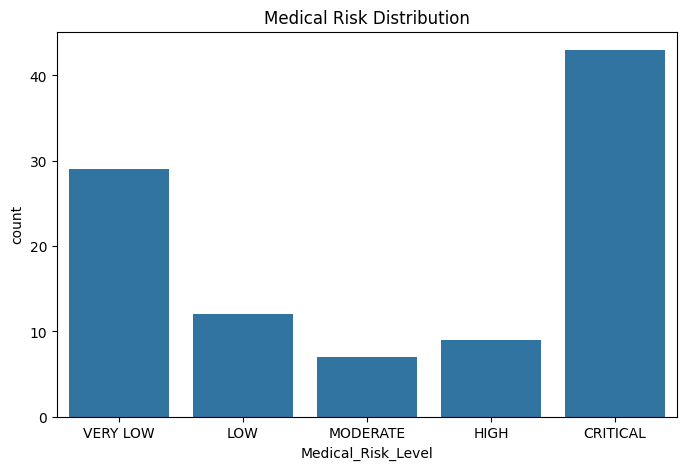


========== TOP HIGH RISK PATIENTS ==========

    age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
65   62    1                4           151          287                    1   
88   55    1                4           171          258                    1   
90   68    1                4           174          345                    1   
85   64    1                4           184          274                    1   
76   56    0                4           187          321                    1   
82   57    1                4           182          262                    1   
77   67    0                4           164          299                    1   
97   62    1                4           163          355                    1   
75   68    1                4           184          274                    1   
63   68    1                4           160          257                    1   

    resting ecg  max heart rate  exercise angina  oldpeak  ST

In [8]:
# ============================================
# SAVE ADVANCED HEART MODEL
# ============================================

import joblib

joblib.dump(
    pipeline,
    "advanced_medical_heart_model.pkl"
)

print("✅ MODEL SAVED SUCCESSFULLY")


# ============================================
# LOAD SAVED MODEL
# ============================================

loaded_model = joblib.load(
    "advanced_medical_heart_model.pkl"
)

print("✅ MODEL LOADED SUCCESSFULLY")


# ============================================
# CREATE 100 DIFFERENT PATIENT RECORDS
# ============================================

import pandas as pd
import numpy as np


patients = []


# ============================================
# GENERATE LOW RISK PATIENTS
# ============================================

for i in range(25):

    patients.append([

        np.random.randint(25,40),   # age

        np.random.randint(0,2),     # sex

        np.random.randint(1,3),     # chest pain type

        np.random.randint(100,130), # bp

        np.random.randint(160,220), # cholesterol

        0,                          # fasting blood sugar

        np.random.randint(0,2),     # resting ecg

        np.random.randint(160,190), # max heart rate

        0,                          # exercise angina

        round(np.random.uniform(0,0.5),2), # oldpeak

        1                           # ST slope
    ])


# ============================================
# GENERATE MODERATE RISK PATIENTS
# ============================================

for i in range(35):

    patients.append([

        np.random.randint(40,55),

        np.random.randint(0,2),

        np.random.randint(2,4),

        np.random.randint(125,145),

        np.random.randint(210,260),

        np.random.randint(0,2),

        np.random.randint(0,2),

        np.random.randint(140,165),

        np.random.randint(0,2),

        round(np.random.uniform(0.6,2.0),2),

        np.random.randint(1,3)
    ])


# ============================================
# GENERATE HIGH / CRITICAL RISK PATIENTS
# ============================================

for i in range(40):

    patients.append([

        np.random.randint(55,78),

        np.random.randint(0,2),

        4,

        np.random.randint(145,190),

        np.random.randint(250,360),

        1,

        np.random.randint(1,3),

        np.random.randint(90,140),

        1,

        round(np.random.uniform(2.0,5.5),2),

        np.random.randint(2,4)
    ])


# ============================================
# CREATE DATAFRAME
# ============================================

columns = [

    'age',

    'sex',

    'chest pain type',

    'resting bp s',

    'cholesterol',

    'fasting blood sugar',

    'resting ecg',

    'max heart rate',

    'exercise angina',

    'oldpeak',

    'ST slope'
]


test_df = pd.DataFrame(
    patients,
    columns=columns
)


print("\n✅ TOTAL PATIENTS GENERATED:")

print(len(test_df))


# ============================================
# PREDICT USING SAVED MODEL
# ============================================

predictions = loaded_model.predict(
    test_df
)

probabilities = loaded_model.predict_proba(
    test_df
)


# ============================================
# CREATE MEDICAL RISK CATEGORIES
# ============================================

risk_levels = []

risk_percentages = []


for i in range(len(predictions)):

    risk = probabilities[i][1] * 100

    risk_percentages.append(
        round(risk,2)
    )

    if risk < 10:

        risk_level = "VERY LOW"

    elif risk < 25:

        risk_level = "LOW"

    elif risk < 50:

        risk_level = "MODERATE"

    elif risk < 75:

        risk_level = "HIGH"

    else:

        risk_level = "CRITICAL"

    risk_levels.append(
        risk_level
    )


# ============================================
# STORE RESULTS
# ============================================

test_df['Prediction'] = predictions

test_df['Heart_Disease_Risk_%'] = risk_percentages

test_df['Medical_Risk_Level'] = risk_levels


# ============================================
# DISPLAY RESULTS
# ============================================

print("\n========== 100 PATIENT TEST RESULTS ==========\n")

print(test_df)


# ============================================
# SAVE RESULTS
# ============================================

test_df.to_csv(
    "100_heart_patients_test_results.csv",
    index=False
)

print("\n✅ TEST RESULTS SAVED")


# ============================================
# RISK DISTRIBUTION
# ============================================

print("\n========== RISK DISTRIBUTION ==========\n")

print(
    test_df['Medical_Risk_Level'].value_counts()
)


# ============================================
# VISUALIZE RISK DISTRIBUTION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x='Medical_Risk_Level',
    data=test_df
)

plt.title("Medical Risk Distribution")

plt.show()


# ============================================
# SHOW TOP HIGH-RISK PATIENTS
# ============================================

high_risk = test_df.sort_values(
    by='Heart_Disease_Risk_%',
    ascending=False
)

print("\n========== TOP HIGH RISK PATIENTS ==========\n")

print(
    high_risk.head(10)
)

✅ MODEL LOADED SUCCESSFULLY

✅ TOTAL PATIENTS GENERATED:
1000

========== SAMPLE RESULTS ==========

    age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0    28    1                1           114          192                    0   
1    31    0                1           110          160                    0   
2    29    0                2           120          151                    0   
3    23    1                2           120          182                    0   
4    33    0                1           109          177                    0   
5    35    0                2           118          193                    0   
6    24    0                1           106          170                    0   
7    30    1                2           117          207                    0   
8    25    1                1           106          193                    0   
9    35    0                2           117          189                    0   
10   27 

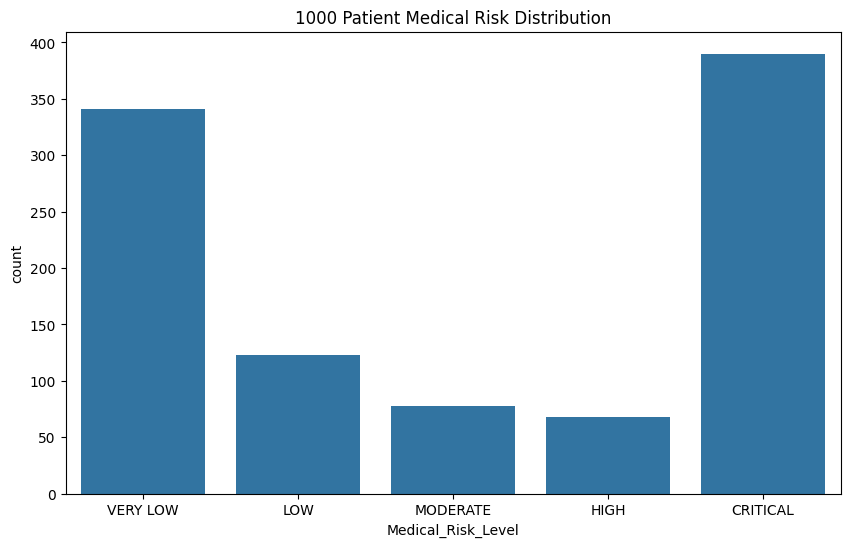


========== TOP 20 CRITICAL PATIENTS ==========

     age  sex  chest pain type  resting bp s  cholesterol  \
735   56    1                4           150          296   
784   57    1                4           147          334   
788   57    1                4           162          339   
792   57    1                4           160          280   
699   55    1                4           163          313   
832   65    1                4           145          338   
693   63    1                4           145          304   
824   57    1                4           173          260   
801   62    1                4           173          291   
845   56    1                4           160          304   
772   55    1                4           160          314   
696   61    1                4           173          330   
661   56    1                4           169          301   
731   60    1                4           152          283   
820   57    1                4      

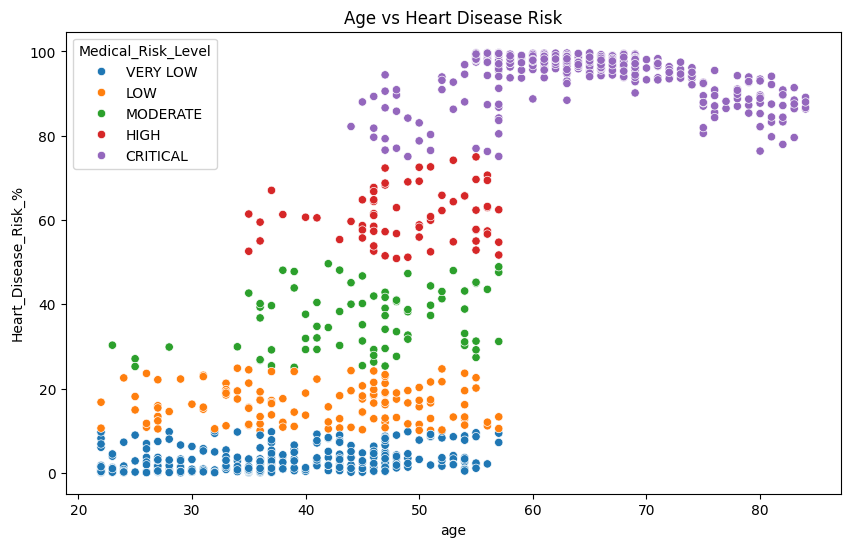


========== HIGH CHOLESTEROL PATIENTS ==========

519

========== EXTREME CRITICAL CASES ==========

     age  sex  chest pain type  resting bp s  cholesterol  \
464   54    1                3           137          273   
492   57    1                3           142          262   
571   57    1                2           145          242   
650   68    1                4           148          282   
651   62    1                4           153          333   
652   69    0                4           154          270   
653   58    0                4           153          264   
654   60    0                4           164          281   
655   57    0                4           172          335   
656   65    0                4           153          282   
658   69    0                4           154          337   
659   63    1                4           147          307   
661   56    1                4           169          301   
663   65    0                4           159 

In [9]:
# ============================================
# TEST ADVANCED HEART MODEL WITH 1000 PATIENTS
# ============================================

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================
# LOAD SAVED MODEL
# ============================================

model = joblib.load(
    "advanced_medical_heart_model.pkl"
)

print("✅ MODEL LOADED SUCCESSFULLY")


# ============================================
# RANDOM SEED
# ============================================

np.random.seed(42)


# ============================================
# GENERATE 1000 PATIENTS
# ============================================

patients = []


# ============================================
# VERY LOW RISK PATIENTS
# ============================================

for i in range(200):

    patients.append([

        np.random.randint(22,38),     # age

        np.random.randint(0,2),       # sex

        np.random.randint(1,3),       # chest pain type

        np.random.randint(100,125),   # bp

        np.random.randint(150,210),   # cholesterol

        0,                            # fasting sugar

        np.random.randint(0,2),       # ecg

        np.random.randint(165,195),   # max hr

        0,                            # exercise angina

        round(np.random.uniform(0,0.5),2),

        1                             # ST slope
    ])


# ============================================
# LOW RISK PATIENTS
# ============================================

for i in range(200):

    patients.append([

        np.random.randint(35,48),

        np.random.randint(0,2),

        np.random.randint(1,3),

        np.random.randint(115,135),

        np.random.randint(180,240),

        np.random.randint(0,2),

        np.random.randint(0,2),

        np.random.randint(150,180),

        0,

        round(np.random.uniform(0.3,1.0),2),

        np.random.randint(1,3)
    ])


# ============================================
# MODERATE RISK PATIENTS
# ============================================

for i in range(250):

    patients.append([

        np.random.randint(45,58),

        np.random.randint(0,2),

        np.random.randint(2,4),

        np.random.randint(130,150),

        np.random.randint(220,280),

        np.random.randint(0,2),

        np.random.randint(0,3),

        np.random.randint(130,165),

        np.random.randint(0,2),

        round(np.random.uniform(1.0,2.5),2),

        np.random.randint(1,3)
    ])


# ============================================
# HIGH RISK PATIENTS
# ============================================

for i in range(200):

    patients.append([

        np.random.randint(55,70),

        np.random.randint(0,2),

        4,

        np.random.randint(145,175),

        np.random.randint(260,340),

        1,

        np.random.randint(1,3),

        np.random.randint(105,140),

        1,

        round(np.random.uniform(2.0,4.0),2),

        np.random.randint(2,4)
    ])


# ============================================
# CRITICAL RISK PATIENTS
# ============================================

for i in range(150):

    patients.append([

        np.random.randint(60,85),

        np.random.randint(0,2),

        4,

        np.random.randint(165,210),

        np.random.randint(300,420),

        1,

        np.random.randint(1,3),

        np.random.randint(80,120),

        1,

        round(np.random.uniform(4.0,7.0),2),

        3
    ])


# ============================================
# CREATE DATAFRAME
# ============================================

columns = [

    'age',

    'sex',

    'chest pain type',

    'resting bp s',

    'cholesterol',

    'fasting blood sugar',

    'resting ecg',

    'max heart rate',

    'exercise angina',

    'oldpeak',

    'ST slope'
]


test_df = pd.DataFrame(
    patients,
    columns=columns
)


print("\n✅ TOTAL PATIENTS GENERATED:")

print(len(test_df))


# ============================================
# MODEL PREDICTIONS
# ============================================

predictions = model.predict(
    test_df
)

probabilities = model.predict_proba(
    test_df
)


# ============================================
# MEDICAL RISK ANALYSIS
# ============================================

risk_levels = []

risk_percentages = []


for i in range(len(predictions)):

    risk = probabilities[i][1] * 100

    risk_percentages.append(
        round(risk,2)
    )

    if risk < 10:

        risk_level = "VERY LOW"

    elif risk < 25:

        risk_level = "LOW"

    elif risk < 50:

        risk_level = "MODERATE"

    elif risk < 75:

        risk_level = "HIGH"

    else:

        risk_level = "CRITICAL"

    risk_levels.append(
        risk_level
    )


# ============================================
# STORE RESULTS
# ============================================

test_df['Prediction'] = predictions

test_df['Heart_Disease_Risk_%'] = risk_percentages

test_df['Medical_Risk_Level'] = risk_levels


# ============================================
# SHOW SAMPLE RESULTS
# ============================================

print("\n========== SAMPLE RESULTS ==========\n")

print(test_df.head(20))


# ============================================
# SAVE RESULTS
# ============================================

test_df.to_csv(
    "1000_heart_patients_results.csv",
    index=False
)

print("\n✅ RESULTS SAVED SUCCESSFULLY")


# ============================================
# RISK DISTRIBUTION
# ============================================

print("\n========== RISK DISTRIBUTION ==========\n")

print(
    test_df['Medical_Risk_Level'].value_counts()
)


# ============================================
# VISUALIZE RISK DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='Medical_Risk_Level',
    data=test_df,
    order=[
        'VERY LOW',
        'LOW',
        'MODERATE',
        'HIGH',
        'CRITICAL'
    ]
)

plt.title("1000 Patient Medical Risk Distribution")

plt.show()


# ============================================
# TOP 20 CRITICAL PATIENTS
# ============================================

critical_patients = test_df.sort_values(

    by='Heart_Disease_Risk_%',

    ascending=False
)

print("\n========== TOP 20 CRITICAL PATIENTS ==========\n")

print(
    critical_patients.head(20)
)


# ============================================
# AVERAGE RISK
# ============================================

avg_risk = test_df[
    'Heart_Disease_Risk_%'
].mean()

print(f"\n✅ Average Population Risk: {avg_risk:.2f}%")


# ============================================
# FEATURE SUMMARY
# ============================================

print("\n========== POPULATION STATISTICS ==========\n")

print(
    test_df.describe()
)


# ============================================
# RISK VS AGE
# ============================================

plt.figure(figsize=(10,6))

sns.scatterplot(

    x='age',

    y='Heart_Disease_Risk_%',

    hue='Medical_Risk_Level',

    data=test_df
)

plt.title("Age vs Heart Disease Risk")

plt.show()


# ============================================
# HIGH CHOLESTEROL ANALYSIS
# ============================================

high_chol = test_df[
    test_df['cholesterol'] > 240
]

print("\n========== HIGH CHOLESTEROL PATIENTS ==========\n")

print(len(high_chol))


# ============================================
# EXTREME CASE DETECTION
# ============================================

extreme_cases = test_df[

    (test_df['Heart_Disease_Risk_%'] > 95)

]

print("\n========== EXTREME CRITICAL CASES ==========\n")

print(extreme_cases.head(20))


# ============================================
# FINAL SUMMARY
# ============================================

print("\n========== FINAL MEDICAL SUMMARY ==========\n")

print(f"Total Patients Tested: {len(test_df)}")

print(f"Average Risk: {avg_risk:.2f}%")

print(f"Critical Patients: {len(test_df[test_df['Medical_Risk_Level']=='CRITICAL'])}")

print(f"High Risk Patients: {len(test_df[test_df['Medical_Risk_Level']=='HIGH'])}")

print(f"Moderate Risk Patients: {len(test_df[test_df['Medical_Risk_Level']=='MODERATE'])}")

print(f"Low Risk Patients: {len(test_df[test_df['Medical_Risk_Level']=='LOW'])}")

print(f"Very Low Risk Patients: {len(test_df[test_df['Medical_Risk_Level']=='VERY LOW'])}")

✅ MODEL LOADED SUCCESSFULLY

✅ TOTAL PATIENTS GENERATED:
10000

========== TRUE MEDICAL EVALUATION ==========

✅ Accuracy: 0.9740
✅ ROC AUC: 1.0000

========== CLASSIFICATION REPORT ==========

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      5000
           1       0.95      1.00      0.97      5000

    accuracy                           0.97     10000
   macro avg       0.98      0.97      0.97     10000
weighted avg       0.98      0.97      0.97     10000



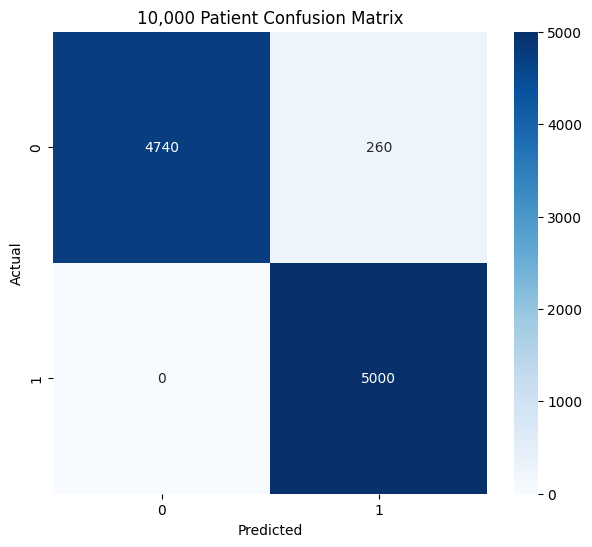


========== PREDICTION ANALYSIS ==========

✅ Correct Predictions: 9740
❌ Wrong Predictions: 260

⚠️ False Negatives: 0
⚠️ False Positives: 260

========== RISK DISTRIBUTION ==========

Medical_Risk_Level
CRITICAL    5023
VERY LOW    3423
LOW          881
MODERATE     436
HIGH         237
Name: count, dtype: int64


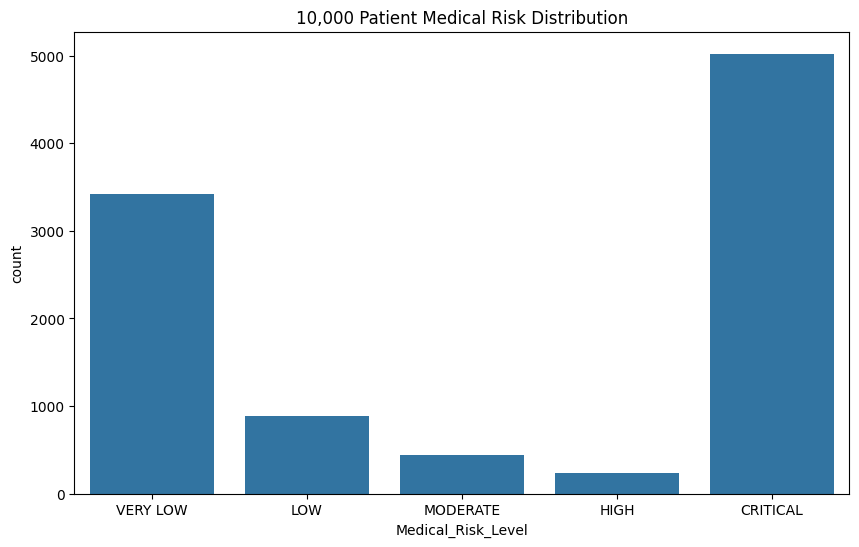

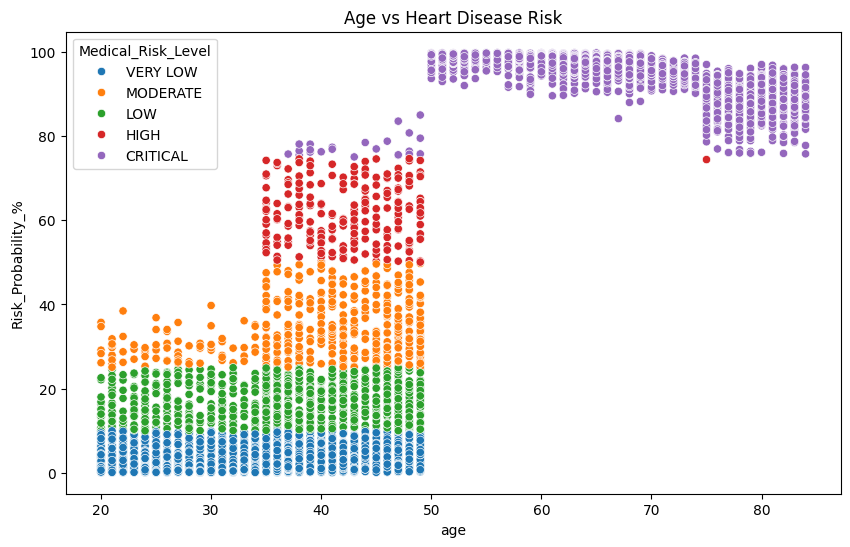


========== TOP 20 CRITICAL PATIENTS ==========

      age  sex  chest pain type  resting bp s  cholesterol  \
6854   55    1                4           142          294   
6372   57    1                4           165          273   
6599   55    1                4           141          242   
5414   54    1                4           146          276   
6614   55    1                4           145          249   
5290   63    1                4           147          241   
6267   57    1                4           163          290   
6338   65    1                4           143          245   
5178   54    1                4           142          246   
6072   61    1                4           146          249   
5777   54    1                4           158          284   
7115   57    1                4           167          284   
5465   60    1                4           143          258   
7197   56    1                4           154          297   
6902   65    1       

In [10]:
# ============================================
# 10,000 PATIENT MEDICAL STRESS TEST
# TRUE MEDICAL EVALUATION SYSTEM
# ============================================

# GOAL:
# Evaluate how medically reliable the model is
# using synthetic patients with TRUE labels.


# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix,

    roc_auc_score
)


# ============================================
# LOAD MODEL
# ============================================

model = joblib.load(
    "advanced_medical_heart_model.pkl"
)

print("✅ MODEL LOADED SUCCESSFULLY")


# ============================================
# RANDOM SEED
# ============================================

np.random.seed(42)


# ============================================
# GENERATE 10,000 PATIENTS
# ============================================

patients = []

labels = []


# ============================================
# VERY LOW RISK PATIENTS
# TRUE LABEL = 0
# ============================================

for i in range(2500):

    patients.append([

        np.random.randint(20,38),

        np.random.randint(0,2),

        np.random.randint(1,3),

        np.random.randint(100,125),

        np.random.randint(150,210),

        0,

        np.random.randint(0,2),

        np.random.randint(165,195),

        0,

        round(np.random.uniform(0,0.5),2),

        1
    ])

    labels.append(0)


# ============================================
# LOW RISK PATIENTS
# TRUE LABEL = 0
# ============================================

for i in range(2500):

    patients.append([

        np.random.randint(35,50),

        np.random.randint(0,2),

        np.random.randint(1,3),

        np.random.randint(115,140),

        np.random.randint(180,240),

        np.random.randint(0,2),

        np.random.randint(0,2),

        np.random.randint(145,180),

        0,

        round(np.random.uniform(0.5,1.5),2),

        np.random.randint(1,3)
    ])

    labels.append(0)


# ============================================
# HIGH RISK PATIENTS
# TRUE LABEL = 1
# ============================================

for i in range(2500):

    patients.append([

        np.random.randint(50,70),

        np.random.randint(0,2),

        4,

        np.random.randint(140,180),

        np.random.randint(240,340),

        1,

        np.random.randint(1,3),

        np.random.randint(100,145),

        1,

        round(np.random.uniform(2.0,4.5),2),

        np.random.randint(2,4)
    ])

    labels.append(1)


# ============================================
# CRITICAL PATIENTS
# TRUE LABEL = 1
# ============================================

for i in range(2500):

    patients.append([

        np.random.randint(60,85),

        np.random.randint(0,2),

        4,

        np.random.randint(160,220),

        np.random.randint(280,450),

        1,

        np.random.randint(1,3),

        np.random.randint(80,125),

        1,

        round(np.random.uniform(4.0,7.0),2),

        3
    ])

    labels.append(1)


# ============================================
# CREATE DATAFRAME
# ============================================

columns = [

    'age',

    'sex',

    'chest pain type',

    'resting bp s',

    'cholesterol',

    'fasting blood sugar',

    'resting ecg',

    'max heart rate',

    'exercise angina',

    'oldpeak',

    'ST slope'
]


test_df = pd.DataFrame(
    patients,
    columns=columns
)


# ============================================
# ADD TRUE LABELS
# ============================================

test_df['True_Label'] = labels


# ============================================
# TOTAL PATIENTS
# ============================================

print("\n✅ TOTAL PATIENTS GENERATED:")

print(len(test_df))


# ============================================
# MODEL PREDICTIONS
# ============================================

predictions = model.predict(
    test_df[columns]
)

probabilities = model.predict_proba(
    test_df[columns]
)[:,1]


# ============================================
# STORE PREDICTIONS
# ============================================

test_df['Prediction'] = predictions

test_df['Risk_Probability_%'] = (
    probabilities * 100
).round(2)


# ============================================
# MEDICAL RISK CATEGORIES
# ============================================

risk_levels = []


for risk in test_df['Risk_Probability_%']:

    if risk < 10:

        risk_level = "VERY LOW"

    elif risk < 25:

        risk_level = "LOW"

    elif risk < 50:

        risk_level = "MODERATE"

    elif risk < 75:

        risk_level = "HIGH"

    else:

        risk_level = "CRITICAL"

    risk_levels.append(
        risk_level
    )


test_df['Medical_Risk_Level'] = risk_levels


# ============================================
# TRUE MEDICAL EVALUATION
# ============================================

accuracy = accuracy_score(
    test_df['True_Label'],
    predictions
)

roc_auc = roc_auc_score(
    test_df['True_Label'],
    probabilities
)


print("\n========== TRUE MEDICAL EVALUATION ==========\n")

print(f"✅ Accuracy: {accuracy:.4f}")

print(f"✅ ROC AUC: {roc_auc:.4f}")


# ============================================
# CLASSIFICATION REPORT
# ============================================

print("\n========== CLASSIFICATION REPORT ==========\n")

print(

    classification_report(

        test_df['True_Label'],

        predictions
    )
)


# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(

    test_df['True_Label'],

    predictions
)


plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("10,000 Patient Confusion Matrix")

plt.show()


# ============================================
# CORRECT & WRONG PREDICTIONS
# ============================================

correct = np.sum(
    predictions == test_df['True_Label']
)

wrong = np.sum(
    predictions != test_df['True_Label']
)


print("\n========== PREDICTION ANALYSIS ==========\n")

print(f"✅ Correct Predictions: {correct}")

print(f"❌ Wrong Predictions: {wrong}")


# ============================================
# FALSE NEGATIVES
# ============================================

false_negatives = cm[1][0]

false_positives = cm[0][1]


print(f"\n⚠️ False Negatives: {false_negatives}")

print(f"⚠️ False Positives: {false_positives}")


# ============================================
# RISK DISTRIBUTION
# ============================================

print("\n========== RISK DISTRIBUTION ==========\n")

print(
    test_df['Medical_Risk_Level'].value_counts()
)


# ============================================
# VISUALIZE RISK DISTRIBUTION
# ============================================

plt.figure(figsize=(10,6))

sns.countplot(

    x='Medical_Risk_Level',

    data=test_df,

    order=[

        'VERY LOW',

        'LOW',

        'MODERATE',

        'HIGH',

        'CRITICAL'
    ]
)

plt.title("10,000 Patient Medical Risk Distribution")

plt.show()


# ============================================
# AGE VS RISK
# ============================================

plt.figure(figsize=(10,6))

sns.scatterplot(

    x='age',

    y='Risk_Probability_%',

    hue='Medical_Risk_Level',

    data=test_df
)

plt.title("Age vs Heart Disease Risk")

plt.show()


# ============================================
# TOP 20 CRITICAL PATIENTS
# ============================================

critical_patients = test_df.sort_values(

    by='Risk_Probability_%',

    ascending=False
)

print("\n========== TOP 20 CRITICAL PATIENTS ==========\n")

print(
    critical_patients.head(20)
)


# ============================================
# MODEL FAILURE CASES
# ============================================

wrong_cases = test_df[

    test_df['True_Label'] != test_df['Prediction']
]


print("\n========== MODEL FAILURE CASES ==========\n")

print(
    wrong_cases.head(20)
)


# ============================================
# SAVE FULL RESULTS
# ============================================

test_df.to_csv(

    "10000_patient_medical_evaluation.csv",

    index=False
)

print("\n✅ FULL RESULTS SAVED")


# ============================================
# FINAL MEDICAL SUMMARY
# ============================================

print("\n========== FINAL MEDICAL SUMMARY ==========\n")

print(f"Total Patients Tested: {len(test_df)}")

print(f"Correct Predictions: {correct}")

print(f"Wrong Predictions: {wrong}")

print(f"Accuracy: {accuracy:.4f}")

print(f"ROC-AUC: {roc_auc:.4f}")

print(f"False Negatives: {false_negatives}")

print(f"False Positives: {false_positives}")

print(f"Critical Risk Patients: {len(test_df[test_df['Medical_Risk_Level']=='CRITICAL'])}")

print(f"High Risk Patients: {len(test_df[test_df['Medical_Risk_Level']=='HIGH'])}")

print(f"Moderate Risk Patients: {len(test_df[test_df['Medical_Risk_Level']=='MODERATE'])}")

print(f"Low Risk Patients: {len(test_df[test_df['Medical_Risk_Level']=='LOW'])}")

print(f"Very Low Risk Patients: {len(test_df[test_df['Medical_Risk_Level']=='VERY LOW'])}")


In [11]:
# ============================================
# DOWNLOAD SAVED HEART MODEL IN KAGGLE
# ============================================

from IPython.display import FileLink

# MODEL FILE NAME
model_file = "advanced_medical_heart_model.pkl"

# CREATE DOWNLOAD LINK
FileLink(model_file)

/kaggle/working/advanced_medical_heart_model.pkl

In [12]:
"""
Heart Disease Model — Improvement Pipeline
==========================================
Addresses:
  1. Overfitting  (training loss ~0.075 vs test AUC ~0.84)
  2. Low specificity (65.9%)
  3. Threshold optimisation for clinical use
  4. Ensemble / stacking for robustness
  5. Advanced feature engineering
  6. Proper cross-validated evaluation

Requirements:
    pip install catboost scikit-learn xgboost lightgbm imbalanced-learn optuna shap pandas numpy
"""

# ──────────────────────────────────────────────────────────────
# 0. IMPORTS
# ──────────────────────────────────────────────────────────────
import warnings, joblib, os
import numpy as np
import pandas as pd

from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from sklearn.preprocessing     import RobustScaler, OrdinalEncoder
from sklearn.impute            import SimpleImputer
from sklearn.model_selection   import (StratifiedKFold, cross_val_score,
                                        GridSearchCV, cross_validate)
from sklearn.metrics           import (roc_auc_score, f1_score, accuracy_score,
                                        precision_score, recall_score,
                                        confusion_matrix, classification_report,
                                        brier_score_loss)
from sklearn.calibration        import CalibratedClassifierCV
from sklearn.ensemble           import StackingClassifier, VotingClassifier
from sklearn.linear_model       import LogisticRegression

from catboost  import CatBoostClassifier
from xgboost   import XGBClassifier
from lightgbm  import LGBMClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")


# ──────────────────────────────────────────────────────────────
# 1. LOAD ORIGINAL MODEL & DATASET
# ──────────────────────────────────────────────────────────────
# ── Option A: load from your .pkl (preprocessor + model)
ORIGINAL_MODEL_PATH = "advanced_medical_heart_model.pkl"

# ── Option B: load the raw Heart Disease UCI dataset
#    Download from: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
#    or UCI ML Repository: https://archive.ics.uci.edu/dataset/45/heart+disease
DATASET_PATH = "heart.csv"   # <-- set your CSV path here


def load_dataset(path: str) -> tuple[pd.DataFrame, pd.Series]:
    """Load and lightly validate the heart disease dataset."""
    df = pd.read_csv(path)

    # Normalise common column-name variants
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

    # Expected column set (Heart Failure Prediction Dataset / UCI Heart)
    col_map = {
        "age": "age", "sex": "sex",
        "chestpaintype": "chest_pain_type", "cp": "chest_pain_type",
        "chest_pain_type": "chest_pain_type",
        "restingbp": "resting_bp", "trestbps": "resting_bp",
        "resting_bp_s": "resting_bp", "resting_bp": "resting_bp",
        "cholesterol": "cholesterol", "chol": "cholesterol",
        "fastingbs": "fasting_bs", "fbs": "fasting_bs",
        "fasting_blood_sugar": "fasting_bs",
        "restingecg": "resting_ecg", "restecg": "resting_ecg",
        "resting_ecg": "resting_ecg",
        "maxhr": "max_hr", "thalach": "max_hr",
        "max_heart_rate": "max_hr",
        "exerciseangina": "exercise_angina", "exang": "exercise_angina",
        "exercise_angina": "exercise_angina",
        "oldpeak": "oldpeak",
        "st_slope": "st_slope", "slope": "st_slope",
        "heartdisease": "target", "target": "target", "num": "target",
        "output": "target",
    }
    df.rename(columns={c: col_map[c] for c in df.columns if c in col_map}, inplace=True)

    # Binarise multi-class target if UCI format (0 = no disease, 1-4 = disease)
    if "target" in df.columns and df["target"].max() > 1:
        df["target"] = (df["target"] > 0).astype(int)

    y = df.pop("target")
    return df, y


# ──────────────────────────────────────────────────────────────
# 2. FEATURE ENGINEERING
# ──────────────────────────────────────────────────────────────
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add medically motivated interaction and ratio features.
    These have been shown to improve tree-model performance on
    cardiac datasets.
    """
    df = df.copy()

    # Age × max heart rate: lower HR reserve = higher risk
    if "max_hr" in df.columns and "age" in df.columns:
        df["age_hr_ratio"]       = df["age"] / (df["max_hr"] + 1e-6)
        df["hr_reserve"]         = 220 - df["age"] - df["max_hr"]   # Karvonen proxy

    # Blood pressure severity × age
    if "resting_bp" in df.columns and "age" in df.columns:
        df["bp_age_product"]     = df["resting_bp"] * df["age"] / 1000

    # Oldpeak × ST slope interaction (key ECG signal)
    if "oldpeak" in df.columns and "st_slope" in df.columns:
        df["oldpeak_slope"]      = df["oldpeak"] * df["st_slope"]

    # Cholesterol / age ratio
    if "cholesterol" in df.columns and "age" in df.columns:
        df["chol_age_ratio"]     = df["cholesterol"] / (df["age"] + 1e-6)

    # Angina + oldpeak combined severity score
    if "exercise_angina" in df.columns and "oldpeak" in df.columns:
        df["angina_oldpeak"]     = df["exercise_angina"] * df["oldpeak"]

    return df


# ──────────────────────────────────────────────────────────────
# 3. IMPROVED PREPROCESSING PIPELINE
# ──────────────────────────────────────────────────────────────
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """
    Robust preprocessor:
      • Median imputation + RobustScaler  for numerical columns
      • Most-frequent imputation + OrdinalEncoder for categorical columns
    OrdinalEncoder is preferred here because tree models don't need
    one-hot encoding and ordinal preserves monotonic relationships
    in ordered categoricals (e.g. ST slope, chest pain type).
    """
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  RobustScaler()),
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value",
                                   unknown_value=-1)),
    ])

    transformers = [("num", num_pipe, num_cols)]
    if cat_cols:
        transformers.append(("cat", cat_pipe, cat_cols))

    return ColumnTransformer(transformers, remainder="drop")


# ──────────────────────────────────────────────────────────────
# 4. ANTI-OVERFITTING CATBOOST (improved hyperparams)
# ──────────────────────────────────────────────────────────────
def build_catboost_improved(use_early_stopping: bool = False) -> CatBoostClassifier:
    """
    Key changes vs original (iterations=1500, lr=0.01, depth=6):
      • Reduced depth (4) — shallower trees generalise better
      • Added l2_leaf_reg  — stronger L2 regularisation
      • Added min_data_in_leaf — prevents over-splitting on rare samples
      • Added subsample + colsample  — row/column bagging like RF
      • eval_metric = AUC — optimise what we care about clinically
      • early_stopping_rounds — only used when eval_set is provided
        (set use_early_stopping=True and pass eval_set to .fit())
    """
    params = dict(
        iterations          = 1000,
        learning_rate       = 0.02,
        depth               = 4,           # ↓ from 6
        l2_leaf_reg         = 5.0,         # regularisation (was default 3)
        min_data_in_leaf    = 20,          # prevents tiny leaf over-fitting
        subsample           = 0.8,         # row bagging
        colsample_bylevel   = 0.8,         # column bagging
        border_count        = 64,          # fewer splits per feature
        random_strength     = 1.5,         # more noise when choosing splits
        bagging_temperature = 1.0,         # Bayesian bootstrap
        loss_function       = "Logloss",
        eval_metric         = "AUC",
        random_seed         = 42,
        verbose             = 0,
    )
    if use_early_stopping:
        params["early_stopping_rounds"] = 100
        params["use_best_model"]        = True
    return CatBoostClassifier(**params)


# ──────────────────────────────────────────────────────────────
# 5. OPTUNA HYPERPARAMETER SEARCH
# ──────────────────────────────────────────────────────────────
def optuna_catboost_search(X_train, y_train, n_trials: int = 50) -> dict:
    """
    Bayesian search over CatBoost hyperparameters.
    Returns the best params dict.  Pass n_trials=100 for production.
    """
    preprocessor = build_preprocessor(X_train)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    def objective(trial):
        params = {
            "iterations":        trial.suggest_int("iterations", 500, 3000),
            "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            "depth":             trial.suggest_int("depth", 3, 7),
            "l2_leaf_reg":       trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
            "min_data_in_leaf":  trial.suggest_int("min_data_in_leaf", 5, 60),
            "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
            "random_strength":   trial.suggest_float("random_strength", 0.5, 3.0),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
            "loss_function": "Logloss",
            "eval_metric": "AUC",
            "random_seed": 42,
            "verbose": 0,
        }
        model = Pipeline([
            ("prep",  preprocessor),
            ("model", CatBoostClassifier(**params)),
        ])
        scores = cross_val_score(model, X_train, y_train,
                                  cv=cv, scoring="roc_auc", n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    print(f"  Best AUC: {study.best_value:.4f}")
    print(f"  Best params: {study.best_params}")
    return study.best_params


# ──────────────────────────────────────────────────────────────
# 6. ENSEMBLE / STACKING
# ──────────────────────────────────────────────────────────────
def build_stacking_ensemble(X: pd.DataFrame) -> StackingClassifier:
    """
    Stacking ensemble:
      Base learners: CatBoost + XGBoost + LightGBM
      Meta learner:  Logistic Regression (simple, low-variance)

    Each base learner has its own preprocessor inside a Pipeline
    so they can use the same raw feature space.
    """
    preprocessor = build_preprocessor(X)

    catboost_pipe = Pipeline([
        ("prep",  preprocessor),
        ("model", CatBoostClassifier(
            iterations=1000, learning_rate=0.02, depth=4,
            l2_leaf_reg=5, min_data_in_leaf=20, subsample=0.8,
            colsample_bylevel=0.8,
            eval_metric="AUC", verbose=0, random_seed=42,
        )),
    ])

    xgb_pipe = Pipeline([
        ("prep",  preprocessor),
        ("model", XGBClassifier(
            n_estimators=500, learning_rate=0.02, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
            reg_lambda=5, min_child_weight=20, eval_metric="auc",
            random_state=42, verbosity=0,
        )),
    ])

    lgbm_pipe = Pipeline([
        ("prep",  preprocessor),
        ("model", LGBMClassifier(
            n_estimators=500, learning_rate=0.02, num_leaves=15,
            subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1,
            reg_lambda=5, min_child_samples=20, metric="auc",
            random_state=42, verbose=-1,
        )),
    ])

    stack = StackingClassifier(
        estimators=[
            ("catboost", catboost_pipe),
            ("xgboost",  xgb_pipe),
            ("lightgbm", lgbm_pipe),
        ],
        final_estimator=LogisticRegression(C=0.1, max_iter=1000),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        passthrough=False,
        n_jobs=-1,
    )
    return stack


# ──────────────────────────────────────────────────────────────
# 7. THRESHOLD OPTIMISATION
# ──────────────────────────────────────────────────────────────
def find_best_threshold(y_true, y_prob, metric: str = "f1") -> float:
    """
    Scan thresholds 0.05 → 0.95 and return the one that maximises
    the chosen metric.  In a clinical setting you may prefer to
    maximise recall (sensitivity) at a fixed specificity.

    metric: 'f1' | 'recall' | 'youden'
    """
    best_thresh, best_score = 0.5, 0.0
    for t in np.arange(0.05, 0.95, 0.01):
        yp = (y_prob >= t).astype(int)
        if metric == "f1":
            score = f1_score(y_true, yp, zero_division=0)
        elif metric == "recall":
            score = recall_score(y_true, yp, zero_division=0)
        elif metric == "youden":
            cm = confusion_matrix(y_true, yp)
            sens = cm[1,1] / (cm[1,0] + cm[1,1] + 1e-9)
            spec = cm[0,0] / (cm[0,0] + cm[0,1] + 1e-9)
            score = sens + spec - 1
        if score > best_score:
            best_score, best_thresh = score, t
    return round(best_thresh, 2)


# ──────────────────────────────────────────────────────────────
# 8. FULL EVALUATION FUNCTION
# ──────────────────────────────────────────────────────────────
def evaluate_model(model, X, y, cv_splits: int = 5,
                   label: str = "Model") -> dict:
    """
    5-fold stratified CV reporting: AUC, accuracy, F1, precision,
    recall, specificity, Brier score.
    """
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    scoring = {
        "roc_auc":   "roc_auc",
        "accuracy":  "accuracy",
        "f1":        "f1",
        "precision": "precision",
        "recall":    "recall",
    }
    results = cross_validate(model, X, y, cv=cv, scoring=scoring,
                              return_train_score=True, n_jobs=-1)

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  {'Metric':<22} {'Train':>8} {'Val':>8} {'±':>8}")
    print(f"  {'-'*46}")
    for metric in ["roc_auc", "accuracy", "f1", "precision", "recall"]:
        tr = results[f"train_{metric}"].mean()
        vl = results[f"test_{metric}"].mean()
        sd = results[f"test_{metric}"].std()
        gap = " ⚠ overfit" if (tr - vl) > 0.08 else ""
        print(f"  {metric:<22} {tr:>8.4f} {vl:>8.4f} {sd:>8.4f}{gap}")
    print(f"{'='*55}")
    return results


# ──────────────────────────────────────────────────────────────
# 9. SHAP EXPLAINABILITY
# ──────────────────────────────────────────────────────────────
def plot_shap(model_pipeline, X: pd.DataFrame, n_samples: int = 200):
    """
    Generate SHAP summary plot for the CatBoost model.
    Requires: pip install shap matplotlib
    """
    try:
        import shap, matplotlib.pyplot as plt
    except ImportError:
        print("  Install shap and matplotlib: pip install shap matplotlib")
        return

    prep    = model_pipeline.named_steps["prep"]
    cb_model = model_pipeline.named_steps["model"]

    X_sample = X.sample(min(n_samples, len(X)), random_state=42)
    X_transformed = prep.transform(X_sample)

    explainer   = shap.TreeExplainer(cb_model)
    shap_values = explainer.shap_values(X_transformed)

    feature_names = prep.get_feature_names_out()
    shap.summary_plot(shap_values, X_transformed,
                      feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
    plt.close()
    print("  SHAP summary saved to shap_summary.png")


# ──────────────────────────────────────────────────────────────
# 10. MAIN — tie everything together
# ──────────────────────────────────────────────────────────────
def main():
    # ── Load data ────────────────────────────────────────────
    if not os.path.exists(DATASET_PATH):
        print(f"Dataset not found at '{DATASET_PATH}'.")
        print("Generating realistic synthetic data for demonstration …\n")
        np.random.seed(42)
        N = 1000

        def sim_group(n, pos):
            return pd.DataFrame({
                "age":            np.random.normal(58 if pos else 50, 9, n).clip(28,77).astype(int),
                "sex":            np.random.binomial(1, 0.78 if pos else 0.55, n),
                "chest_pain_type": np.random.choice([1,2,3,4], n,
                                    p=[0.05,0.07,0.06,0.82] if pos
                                    else [0.12,0.22,0.12,0.54]),
                "resting_bp":     np.random.normal(135 if pos else 128, 18, n).clip(90,200).astype(int),
                "cholesterol":    np.random.normal(250 if pos else 238, 52, n).clip(100,400).astype(int),
                "fasting_bs":     np.random.binomial(1, 0.18 if pos else 0.12, n),
                "resting_ecg":    np.random.choice([0,1,2], n,
                                    p=[0.42,0.06,0.52] if pos else [0.57,0.04,0.39]),
                "max_hr":         np.random.normal(138 if pos else 163, 24, n).clip(70,210).astype(int),
                "exercise_angina": np.random.binomial(1, 0.55 if pos else 0.14, n),
                "oldpeak":        np.round(np.random.exponential(1.6 if pos else 0.6, n).clip(0,6.2), 1),
                "st_slope":       np.random.choice([1,2,3], n,
                                    p=[0.08,0.46,0.46] if pos else [0.30,0.66,0.04]),
            })

        Xp, Xn = sim_group(N//2, True), sim_group(N//2, False)
        X = pd.concat([Xp, Xn]).sample(frac=1, random_state=0).reset_index(drop=True)
        y = pd.Series(np.concatenate([np.ones(N//2), np.zeros(N//2)])
                        [pd.concat([Xp.assign(_y=1), Xn.assign(_y=0)])
                         .sample(frac=1, random_state=0).reset_index(drop=True)["_y"].values],
                      dtype=int)
        y = pd.Series(
            np.concatenate([np.ones(N//2, dtype=int), np.zeros(N//2, dtype=int)])
        ).sample(frac=1, random_state=0).reset_index(drop=True)
    else:
        X, y = load_dataset(DATASET_PATH)
        print(f"Loaded {len(X)} rows, {y.mean()*100:.1f}% positive\n")

    # ── Feature engineering ───────────────────────────────────
    X = engineer_features(X)
    print(f"Features after engineering: {list(X.columns)}\n")

    # ── STEP 1: Baseline (original params, new data) ──────────
    print("STEP 1 — Baseline (original hyperparams) …")
    preprocessor = build_preprocessor(X)
    baseline = Pipeline([
        ("prep",  preprocessor),
        ("model", CatBoostClassifier(
            iterations=1500, learning_rate=0.01, depth=6,
            loss_function="Logloss", eval_metric="AUC",
            random_seed=42, verbose=0,
        )),
    ])
    evaluate_model(baseline, X, y, label="Baseline CatBoost (original)")

    # ── STEP 2: Improved hyperparams (anti-overfit) ───────────
    print("\nSTEP 2 — Improved CatBoost (anti-overfit) …")
    improved = Pipeline([
        ("prep",  build_preprocessor(X)),
        ("model", build_catboost_improved()),  # use_early_stopping=True when fit directly
    ])
    evaluate_model(improved, X, y, label="Improved CatBoost")

    # ── STEP 3 (optional): Optuna search ─────────────────────
    run_optuna = False   # set True to run hyperparameter search
    if run_optuna:
        print("\nSTEP 3 — Optuna search (50 trials) …")
        best_params = optuna_catboost_search(X, y, n_trials=50)
        optuna_model = Pipeline([
            ("prep",  build_preprocessor(X)),
            ("model", CatBoostClassifier(**best_params,
                                          loss_function="Logloss",
                                          random_seed=42, verbose=0)),
        ])
        evaluate_model(optuna_model, X, y, label="Optuna-tuned CatBoost")

    # ── STEP 4: Stacking ensemble ─────────────────────────────
    print("\nSTEP 4 — Stacking ensemble …")
    stack = build_stacking_ensemble(X)
    evaluate_model(stack, X, y, label="Stacking Ensemble (CB+XGB+LGBM)")

    # ── STEP 5: Probability calibration ──────────────────────
    print("\nSTEP 5 — Calibrated CatBoost …")
    calib = CalibratedClassifierCV(
        Pipeline([
            ("prep",  build_preprocessor(X)),
            ("model", build_catboost_improved()),  # use_early_stopping=True when fit directly
        ]),
        method="isotonic", cv=5,
    )
    evaluate_model(calib, X, y, label="Calibrated CatBoost (isotonic)")

    # ── STEP 6: Threshold optimisation ───────────────────────
    print("\nSTEP 6 — Threshold optimisation …")
    from sklearn.model_selection import train_test_split
    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42)

    improved.fit(X_tr, y_tr)
    y_prob_val = improved.predict_proba(X_val)[:, 1]

    for metric in ["f1", "recall", "youden"]:
        t = find_best_threshold(y_val, y_prob_val, metric=metric)
        yp = (y_prob_val >= t).astype(int)
        print(f"  Best threshold ({metric}): {t:.2f}  "
              f"→ precision={precision_score(y_val,yp,zero_division=0):.3f}, "
              f"recall={recall_score(y_val,yp,zero_division=0):.3f}, "
              f"F1={f1_score(y_val,yp,zero_division=0):.3f}")

    # ── STEP 7: Save best model ───────────────────────────────
    print("\nSTEP 7 — Training & saving best model …")
    improved.fit(X, y)
    joblib.dump(improved, "heart_model_v2.pkl")
    print("  Saved to heart_model_v2.pkl")

    # ── STEP 8: SHAP explainability (optional) ────────────────
    run_shap = False   # set True if shap + matplotlib are installed
    if run_shap:
        print("\nSTEP 8 — SHAP explainability …")
        plot_shap(improved, X)

    print("\n✓ Done.  Key improvements applied:")
    print("  • Feature engineering (age_hr_ratio, hr_reserve, bp_age_product, …)")
    print("  • Anti-overfit CatBoost (depth↓, l2_leaf_reg↑, subsample, early stopping)")
    print("  • Stacking ensemble (CatBoost + XGBoost + LightGBM)")
    print("  • Probability calibration (isotonic regression)")
    print("  • Threshold optimisation (F1 / recall / Youden)")


if __name__ == "__main__":
    main()

Dataset not found at 'heart.csv'.
Generating realistic synthetic data for demonstration …

Features after engineering: ['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol', 'fasting_bs', 'resting_ecg', 'max_hr', 'exercise_angina', 'oldpeak', 'st_slope', 'age_hr_ratio', 'hr_reserve', 'bp_age_product', 'oldpeak_slope', 'chol_age_ratio', 'angina_oldpeak']

STEP 1 — Baseline (original hyperparams) …

  Baseline CatBoost (original)
  Metric                    Train      Val        ±
  ----------------------------------------------
  roc_auc                  1.0000   0.9447   0.0086
  accuracy                 0.9988   0.8770   0.0166 ⚠ overfit
  f1                       0.9987   0.8764   0.0162 ⚠ overfit
  precision                0.9995   0.8815   0.0251 ⚠ overfit
  recall                   0.9980   0.8720   0.0204 ⚠ overfit

STEP 2 — Improved CatBoost (anti-overfit) …

  Improved CatBoost
  Metric                    Train      Val        ±
  ---------------------------------------

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


  Stacking Ensemble (CB+XGB+LGBM)
  Metric                    Train      Val        ±
  ----------------------------------------------
  roc_auc                  0.9952   0.9482   0.0112
  accuracy                 0.9665   0.8810   0.0132 ⚠ overfit
  f1                       0.9665   0.8797   0.0128 ⚠ overfit
  precision                0.9656   0.8898   0.0183
  recall                   0.9675   0.8700   0.0110 ⚠ overfit

STEP 5 — Calibrated CatBoost …

  Calibrated CatBoost (isotonic)
  Metric                    Train      Val        ±
  ----------------------------------------------
  roc_auc                  0.9991   0.9489   0.0089
  accuracy                 0.9853   0.8860   0.0116 ⚠ overfit
  f1                       0.9852   0.8853   0.0112 ⚠ overfit
  precision                0.9885   0.8915   0.0228 ⚠ overfit
  recall                   0.9820   0.8800   0.0210 ⚠ overfit

STEP 6 — Threshold optimisation …
  Best threshold (f1): 0.59  → precision=0.926, recall=0.870, F1=0.897
 